# 14 — Hyperparameter study for the 4B student (Milestone 4)

**Step 3 of 3.** `12_kaggle_artifact_import` → `13_distill_dataset_kaggle` → **`14_hyperparameter_study`**

Notebook 13 wrote the teacher's answers. This notebook takes the 4B student and asks a single
question, twenty-four times over:

> **which training settings actually matter for this task, and by how much?**

## What this notebook is, and is not

This is **not** the "train the final model and evaluate it" notebook. That work moved out. Every
minute of GPU time here goes into the thing Milestone 4 asks for: *training models and
experimenting with different hyperparameters, optimization strategies and regularization
techniques.*

Concretely, the notebook trains **27 QLoRA fine-tunes** of `gemma-3-4b-it`, each on the *same*
rows for the *same* number of optimizer steps, and scores each on the *same* held-back rows. It
then draws eight figures and prints one leaderboard.

## The four families

| family | what is varied | why it is here |
|---|---|---|
| **optimization** | learning rate, schedule shape, optimizer, effective batch, warmup | the levers that decide *whether* it converges |
| **regularization** | LoRA dropout, weight decay | the levers that decide whether it *overfits* |
| **capacity** | LoRA rank, alpha/rank ratio, which modules get adapters | how much trainable surface the task needs |
| **noise** | the same config on three seeds | tells us which gaps above are real |

That last family is the one that makes the rest honest. On 160 rows, two settings that differ by
0.01 in validation loss are indistinguishable. Running the baseline three times measures how big
"indistinguishable" is, and every figure draws that band so a reader can see it.

## Design rules

1. **One factor at a time.** Every config differs from `baseline` in exactly one place, so a
   column of the table can be read as a cause.
2. **Equal compute, not equal wall-clock.** Same rows, same epochs, same effective batch (except
   where batch is the thing being varied). A config does not win by training longer.
3. **Ranked on the best validation loss seen during the run**, not the last one — otherwise the
   3-epoch run is punished for the overfitting it exists to demonstrate.
4. **Nothing is skipped for time.** There is no budget check that abandons the search half way.
   The run is kept short by making each config cheap, not by cutting the experiment.

## Runtime

Roughly **2.5 to 3 hours** on Kaggle's T4. That comes from the arithmetic printed at the end of
step 0, not from a promise: 29 compute units × 160 rows × ~1.4 s/row, plus a 48-row validation
pass three times inside every unit, plus ~10 minutes of setup. Kaggle's ceiling is 12 hours, so
there is room to run the whole thing twice if something needs changing.

## Dependencies

Same guard as notebook 13. Kaggle's torch, numpy and transformers are built against each other.
If pip is allowed to move numpy, the next `import torch` dies with a confusing message about
`METH_CLASS`. A "Save & Run All" job has no kernel to restart, so we pin instead of fixing it
afterwards.

In [1]:
import os

# ONE GPU. This has to be set here, in the first cell, before anything imports torch --
# once torch has looked at the cards, changing it does nothing.
#
# Kaggle gives two T4s. The Trainer counts them, decides to help, and wraps the model in
# nn.DataParallel, which copies it to the second card on every step. A 4-bit model cannot be
# copied that way: its weights come with extra tensors describing how they were shrunk, those
# do not travel with the copy, and the kernel then reads memory that is not there. The run
# dies with "CUDA error: an illegal memory access was encountered" in the middle of the first
# training step, which looks like a hardware fault and is not one.
os.environ["CUDA_VISIBLE_DEVICES"] = "0"

import subprocess, sys, importlib.metadata as _md
from packaging.version import Version

def _ver(pkg):
    try:
        return Version(_md.version(pkg))
    except Exception:
        return None

# pip may add packages, but may not move any of these.
_PIN = ("numpy", "torch", "torchvision", "torchaudio", "scipy", "pandas", "pyarrow")
_lines = [f"{p}=={_md.version(p)}" for p in _PIN if _ver(p) is not None]
_CONSTRAINTS = "/tmp/pip-constraints.txt"
with open(_CONSTRAINTS, "w") as f:
    f.write("\n".join(_lines) + "\n")
print("pinned (pip may not change these):")
for _l in _lines:
    print(f"   {_l}")

_NEED = [("transformers", "4.50.0"), ("accelerate", "0.30.0"), ("peft", "0.11.0"),
         ("bitsandbytes", "0.43.0"), ("torchao", "0.16.0"),
         ("sentencepiece", None), ("hf_transfer", None)]

_missing = []
for _pkg, _minv in _NEED:
    _v = _ver(_pkg)
    if _v is None:
        _missing.append(_pkg)
    elif _minv and _v < Version(_minv):
        _missing.append(f"{_pkg}>={_minv}")

if _missing:
    print(f"\ninstalling: {_missing}")
    _r = subprocess.run([sys.executable, "-m", "pip", "install", "-q",
                         "--no-warn-conflicts", "-c", _CONSTRAINTS, *_missing])
    if _r.returncode != 0:
        print("[WARN] pip exited non-zero -- the import check below is the real test")
else:
    print("\nall dependencies already present, nothing installed")

try:
    import torch
    print(f"\ntorch {torch.__version__}   cuda={torch.cuda.is_available()}   "
          f"gpus visible={torch.cuda.device_count()} (limited to 1 on purpose)")
    if torch.cuda.device_count() > 1:
        print("[WARN] more than one GPU is still visible. CUDA was already awake before "
              "this cell\n       ran. Stop the session and Run All from the top, or step 5 "
              "may fail with\n       'an illegal memory access was encountered'.")
except Exception as _e:
    raise RuntimeError(
        f"torch is broken in this session: {type(_e).__name__}: {_e}\n\n"
        "  1. Right panel -> Session options -> STOP session, then reopen the notebook.\n"
        "  2. Run All again. This cell pins the compiled packages and will not move them.\n"
    ) from _e

pinned (pip may not change these):
   numpy==2.0.2
   torch==2.10.0+cu128
   torchvision==0.25.0+cu128
   torchaudio==2.10.0+cu128
   scipy==1.16.3
   pandas==2.3.3
   pyarrow==24.0.0

installing: ['bitsandbytes', 'torchao>=0.16.0', 'hf_transfer']
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.9/40.9 MB 50.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 65.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 68.2 MB/s eta 0:00:00

torch 2.10.0+cu128   cuda=True   gpus visible=1 (limited to 1 on purpose)


## 0. Settings — the experiment grid

Everything that defines the study is in this one cell.

### The compute unit

Every config gets the same allowance: `SWEEP_TRAIN_ROWS` rows, one epoch, `eff_batch` rows per
optimizer step. That allowance is deliberately small. The point of this notebook is to compare
settings against each other, and a comparison is only as good as the fact that both sides got
the same deal — it is not made better by giving both sides more.

`SWEEP_MAX_SEQ_LEN = 1024` is the other half of keeping the run short. Gemma's vocabulary is
~262k tokens, so the cross-entropy is the dominant cost and it grows linearly with sequence
length. Dropping the window from 1950 to 1024 nearly halves the cost of every run. Rows longer
than that lose tokens **from the front of the prompt**; the farmer's question and the whole
answer always survive. The number of rows this affects is printed in step 4 — report it.

### Why `epochs_curve` is one config and not three

Running 1, 2 and 3 epochs as separate configs costs 1+2+3 = 6 units. Running *one* 3-epoch job
with a validation pass at the end of every epoch costs 3 units and produces the same three
numbers, plus the shape of the curve between them. That curve is the overfitting evidence.

### No time budget

The previous version of this notebook had a check that abandoned untried settings if the clock
ran down. That is gone. If the run is too slow, the fix is to lower `SWEEP_TRAIN_ROWS`, not to
publish a search that quietly stopped early.

In [2]:
import os, sys, json, re, time, random, hashlib, gc, shutil, glob, math
from collections import Counter, defaultdict

os.environ.setdefault("HF_HOME", "/kaggle/temp/hf_cache" if os.path.isdir("/kaggle") else "./hf_cache")
os.environ.setdefault("PYTORCH_CUDA_ALLOC_CONF", "expandable_segments:True")
os.environ.setdefault("PYTORCH_ALLOC_CONF", "expandable_segments:True")
try:
    import hf_transfer  # noqa: F401
    os.environ["HF_HUB_ENABLE_HF_TRANSFER"] = "1"
except ImportError:
    pass

import torch
import pandas as pd

SEED = 13
random.seed(SEED)
torch.manual_seed(SEED)

IS_KAGGLE = os.path.isdir("/kaggle/input") or bool(os.environ.get("KAGGLE_KERNEL_RUN_TYPE"))
WORK_ROOT = "/kaggle/temp" if os.path.isdir("/kaggle/temp") else os.path.abspath("./work")
OUT_ROOT  = "/kaggle/working" if IS_KAGGLE else os.path.abspath("./out")
OUTPUT_DIR  = os.path.join(OUT_ROOT, "hparam_study")
FIG_DIR     = os.path.join(OUTPUT_DIR, "figures")
ADAPTER_DIR = os.path.join(OUTPUT_DIR, "best_adapter")
CKPT_DIR    = os.path.join(WORK_ROOT, "ckpt_tmp")
for d in (OUTPUT_DIR, FIG_DIR, WORK_ROOT):
    os.makedirs(d, exist_ok=True)

# =========================== MAIN SWITCH ===============================================
# True  -> 3 configs, 8 rows each. Proves the notebook runs end to end in ~15 minutes.
# False -> the real study.
SMOKE_TEST = False
# =======================================================================================

# ---- the student -------------------------------------------------------------------------
# The pre-quantized 4-bit copy is tried first: its weights are already 4-bit on disk, so there
# is no on-the-fly quantization step for the loader to skip. Tried in order, first that loads.
STUDENT_TRAIN_IDS = ["unsloth/gemma-3-4b-it-bnb-4bit", "google/gemma-3-4b-it"]
STUDENT_BASE_ID   = "google/gemma-3-4b-it"
STUDENT_MODEL_ID  = STUDENT_BASE_ID

# ---- the compute unit every config gets ---------------------------------------------------
SWEEP_TRAIN_ROWS  = 17   if SMOKE_TEST else 160
MAX_VAL_ROWS      = 4   if SMOKE_TEST else 48
SWEEP_MAX_SEQ_LEN = 512 if SMOKE_TEST else 1024
MAX_SEQ_LEN       = SWEEP_MAX_SEQ_LEN     # one window for training and validation alike
VAL_FRACTION      = 0.06
EVALS_PER_EPOCH   = 3
MAX_ROWS_AT_ONCE  = 2                     # memory ceiling; worked out properly in step 4

# ---- the baseline every config is measured against ----------------------------------------
# lora_alpha is 2x lora_r by default on purpose: alpha/r is the strength of the trained part,
# so holding alpha still while changing r would move two things at once. `alpha_ratio_1x`
# exists precisely to test that convention.
BASE = dict(lora_r=16, lora_alpha=32, lr=2e-4, epochs=1,
            dropout=0.05, weight_decay=0.0, sched="cosine", warmup=0.03,
            optim="paged_adamw_8bit", eff_batch=16, modules="all",
            max_grad_norm=1.0, seed=13, eval_each_epoch=False)

ATTN = ["q_proj", "k_proj", "v_proj", "o_proj"]
MLP  = ["gate_proj", "up_proj", "down_proj"]
MODULE_SETS = {"all": ATTN + MLP, "attn": ATTN, "mlp": MLP}

def CFG(label, family, question, **kw):
    """One row of the study. `question` is printed in the table so the write-up can quote it."""
    return dict(BASE, label=label, family=family, question=question, **kw)

SWEEP_CONFIGS = [
    # ---- reference + noise floor ----------------------------------------------------------
    CFG("baseline",        "reference",      "the point everything else is compared to"),
    CFG("seed_07",         "noise",          "how much of any gap below is just luck?", seed=7),
    CFG("seed_21",         "noise",          "how much of any gap below is just luck?", seed=21),

    # ---- optimization strategy -------------------------------------------------------------
    CFG("lr_5e-5",         "optimization",   "is 2e-4 too hot for a 4B student?",  lr=5e-5),
    CFG("lr_1e-4",         "optimization",   "is 2e-4 too hot for a 4B student?",  lr=1e-4),
    CFG("lr_5e-4",         "optimization",   "is 2e-4 too cold?",                  lr=5e-4),
    CFG("sched_linear",    "optimization",   "does the decay shape matter?",       sched="linear"),
    CFG("sched_constant",  "optimization",   "is any decay needed at all?",        sched="constant"),
    CFG("optim_adamw_fp32","optimization",   "what does 8-bit Adam cost in quality?",
        optim="adamw_torch"),
    CFG("optim_adafactor", "optimization",   "can a stateless optimizer keep up?", optim="adafactor"),
    CFG("batch_08",        "optimization",   "smaller steps, noisier gradient",    eff_batch=8),
    CFG("batch_32",        "optimization",   "larger steps, smoother gradient",    eff_batch=32),
    CFG("warmup_0.00",     "optimization",   "is warmup doing anything on a run this short?",
        warmup=0.0),
    CFG("warmup_0.10",     "optimization",   "would more warmup help?",            warmup=0.10),
    CFG("clip_0.3",        "optimization",   "does tighter gradient clipping stabilise it?",
        max_grad_norm=0.3),

    # ---- regularization --------------------------------------------------------------------
    CFG("dropout_0.00",    "regularization", "is LoRA dropout earning its place?", dropout=0.0),
    CFG("dropout_0.10",    "regularization", "would more dropout help?",           dropout=0.10),
    CFG("dropout_0.20",    "regularization", "where does dropout start to hurt?",  dropout=0.20),
    CFG("wd_0.01",         "regularization", "does weight decay help LoRA at all?", weight_decay=0.01),
    CFG("wd_0.10",         "regularization", "how much decay before it bites?",     weight_decay=0.10),

    # ---- capacity ---------------------------------------------------------------------------
    CFG("rank_08",         "capacity",       "how little trainable surface is enough?",
        lora_r=8,  lora_alpha=16),
    CFG("rank_32",         "capacity",       "does more rank keep paying?",  lora_r=32, lora_alpha=64),
    CFG("rank_64",         "capacity",       "where does rank saturate?",    lora_r=64, lora_alpha=128),
    CFG("alpha_ratio_1x",  "capacity",       "is alpha = 2r a real choice or a habit?",
        lora_r=16, lora_alpha=16),
    CFG("attn_only",       "capacity",       "do the MLP adapters matter?",  modules="attn"),
    CFG("mlp_only",        "capacity",       "do the attention adapters matter?", modules="mlp"),

    # ---- epochs / overfitting ----------------------------------------------------------------
    # ONE 3-epoch run with a validation pass at every epoch. Costs 3 units instead of the 6 that
    # separate 1-, 2- and 3-epoch runs would, and additionally shows the shape between them.
    CFG("epochs_curve",    "epochs",         "when does it start memorising?",
        epochs=3, eval_each_epoch=True),
]

if SMOKE_TEST:
    SWEEP_CONFIGS = [c for c in SWEEP_CONFIGS
                     if c["label"] in ("baseline", "lr_5e-4", "epochs_curve")]

# Every config must differ from BASE in at most one place, or the table cannot be read as
# cause and effect. Checked rather than trusted -- it is an easy thing to break while editing.
_VARY_OK = {"label", "family", "question", "lora_alpha"}   # alpha moves with rank by design
for _c in SWEEP_CONFIGS:
    _diff = {k for k in BASE if _c[k] != BASE[k]} - _VARY_OK
    if len(_diff) > 1 and _c["label"] not in ("epochs_curve",):
        raise ValueError(f"{_c['label']} varies {sorted(_diff)} -- one factor at a time, "
                         "or the effect cannot be attributed.")

# ---- what to keep ---------------------------------------------------------------------------
# The winning config is trained once more and its adapter is saved. This is not "the final
# model" -- it is one extra compute unit so the study leaves a usable artifact behind. Set it
# to False if you only want the tables and figures.
SAVE_BEST_ADAPTER = not SMOKE_TEST

if "HF_TOKEN" not in os.environ:
    for loader in (
        lambda: __import__("kaggle_secrets").UserSecretsClient().get_secret("HF_TOKEN"),
        lambda: __import__("google.colab", fromlist=["userdata"]).userdata.get("HF_TOKEN"),
    ):
        try:
            _t = loader()
            if _t:
                os.environ["HF_TOKEN"] = _t
                print("HF_TOKEN loaded from secrets")
                break
        except Exception:
            pass
if "HF_TOKEN" not in os.environ:
    print("[WARN] no HF_TOKEN. Gemma needs one -- step 3 will fail with a 401.")


# ---------------------------------------------------------------------------------------------
# Progress logging.
# ---------------------------------------------------------------------------------------------
RUN_START = time.time()
STEP_LOG = []
_step_state = {"n": None, "name": None, "t0": None}

PLAN = [
    (1, "Load the data from notebook 13"),
    (2, "Split into train and validation"),
    (3, "Load the student model"),
    (4, "Turn the rows into tokens"),
    (5, "Run the hyperparameter study"),
    (6, "Figures"),
    (7, "Leaderboard and findings"),
    (8, "Package everything"),
]

def step(n, name):
    if _step_state["n"] is not None:
        took = (time.time() - _step_state["t0"]) / 60
        STEP_LOG.append((_step_state["n"], _step_state["name"], round(took, 2)))
        print(f"\n--- step {_step_state['n']} done in {took:.1f} min "
              f"(total so far {(time.time()-RUN_START)/60:.1f} min) ---")
    _step_state.update(n=n, name=name, t0=time.time())
    print("\n" + "=" * 78)
    print(f"STEP {n}/{len(PLAN)}  {name}")
    print("=" * 78)

def finish_steps():
    if _step_state["n"] is not None:
        took = (time.time() - _step_state["t0"]) / 60
        STEP_LOG.append((_step_state["n"], _step_state["name"], round(took, 2)))
        _step_state["n"] = None

def minutes_used():
    return (time.time() - RUN_START) / 60

def free_vram(*names):
    for n in names:
        if n in globals():
            del globals()[n]
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.synchronize()

def disk_free_gb(path=None):
    return shutil.disk_usage(path or OUT_ROOT).free / 1e9

def vram_report(tag=""):
    if not torch.cuda.is_available():
        print(f"[{tag}] no GPU -- a 4B model will not train on CPU. Turn on GPU T4 x2.")
        return
    parts = [f"gpu{i} {torch.cuda.mem_get_info(i)[0]/1e9:.1f} GB free"
             for i in range(torch.cuda.device_count())]
    print(f"[{tag}] " + "   ".join(parts) + f"   disk {disk_free_gb():.1f} GB free")


_units = sum(c["epochs"] for c in SWEEP_CONFIGS) + (1 if SAVE_BEST_ADAPTER else 0)
print(f"mode      : {'SMOKE TEST' if SMOKE_TEST else 'FULL STUDY'}")
print(f"student   : {STUDENT_TRAIN_IDS[0]}")
print(f"configs   : {len(SWEEP_CONFIGS)}  ({_units} compute units of "
      f"{SWEEP_TRAIN_ROWS} rows x 1 epoch)")
print(f"families  : {dict(Counter(c['family'] for c in SWEEP_CONFIGS))}")
print(f"window    : {MAX_SEQ_LEN} tokens   validation: up to {MAX_VAL_ROWS} rows")
print(f"output    : {OUTPUT_DIR}")
print("\nnothing in this notebook is skipped for time. If it is too slow, lower "
      "SWEEP_TRAIN_ROWS.")
vram_report("start")

HF_TOKEN loaded from secrets
mode      : FULL STUDY
student   : unsloth/gemma-3-4b-it-bnb-4bit
configs   : 27  (30 compute units of 160 rows x 1 epoch)
families  : {'reference': 1, 'noise': 2, 'optimization': 12, 'regularization': 5, 'capacity': 6, 'epochs': 1}
window    : 1024 tokens   validation: up to 48 rows
output    : /kaggle/working/hparam_study

nothing in this notebook is skipped for time. If it is too slow, lower SWEEP_TRAIN_ROWS.
[start] gpu0 15.5 GB free   disk 20.9 GB free


## 1. Load the data from notebook 13

`dataset_manifest.json` ties everything together. Its `config_hash` is copied into every file
this notebook writes, so any number here can be traced back to the exact data it came from.

Only `train.jsonl` is used. The 28 test questions from notebook 13 are deliberately **not**
touched: this notebook selects settings on validation loss, and a held-out test set that gets
looked at during selection is no longer held out.

In [3]:
step(1, "Load the data from notebook 13")

def _glob1(pat):
    hits = sorted(glob.glob(pat, recursive=True))
    return hits[0] if hits else None

SEARCH_ROOTS = ["/kaggle/input", OUT_ROOT, "."]

def _find(name):
    for root in SEARCH_ROOTS:
        p = _glob1(os.path.join(root, "**", name))
        if p:
            return p
    return None

_man = _find("dataset_manifest.json")
if not _man:
    print("what is in /kaggle/input:")
    for r, d, fs in os.walk("/kaggle/input"):
        if r.replace("/kaggle/input", "").count(os.sep) > 4:
            d[:] = []
            continue
        for f in sorted(fs)[:12]:
            print(f"   {os.path.join(r, f)}")
    raise FileNotFoundError(
        "dataset_manifest.json not found.\n"
        "Attach notebook 13's output: Add Input -> Your Work -> Notebook Output -> "
        "13_distill_dataset_kaggle.\n"
        "It has to be a finished 'Save & Run All' version -- files from a session that is "
        "still open cannot be attached.")

DATASET_MANIFEST = json.load(open(_man, encoding="utf-8"))
DATA_DIR = os.path.dirname(_man)

train_path = os.path.join(DATA_DIR, "train.jsonl")
if not os.path.exists(train_path):
    raise FileNotFoundError(f"train.jsonl is missing from {DATA_DIR}. Notebook 13 did not finish.")

all_rows = [json.loads(l) for l in open(train_path, encoding="utf-8") if l.strip()]
if not all_rows:
    raise RuntimeError("train.jsonl is empty -- notebook 13 kept no rows.")

# The prompts were written with notebook 13's tokenizer. A mismatch means the prompt we train
# on is not the prompt we serve. Compared on the base name, because the unsloth 4-bit copy and
# the Google repo are the same weights and the same tokenizer.
def _base_name(mid):
    return (mid or "").split("/")[-1].replace("-bnb-4bit", "").replace("-unsloth", "").lower()

_built_with = DATASET_MANIFEST.get("student_tokenizer_id")
if _built_with and _base_name(_built_with) != _base_name(STUDENT_BASE_ID):
    raise RuntimeError(
        f"notebook 13 built the prompts with {_built_with}, but this notebook trains "
        f"{STUDENT_BASE_ID}. The chat template is different.")

TEACHER_ID = DATASET_MANIFEST.get("teacher_model_id")
IS_DISTILLATION = bool(TEACHER_ID) and "distillation" in DATASET_MANIFEST.get("method", "")

if DATASET_MANIFEST.get("smoke_test"):
    print("\n" + "!" * 74)
    print("!! the attached data was built with SMOKE_TEST = True in notebook 13.")
    print("!! Whatever this run produces is a plumbing check, not a result. Do not quote it.")
    print("!" * 74 + "\n")

ROW_KINDS = Counter(r.get("kind", "answer") for r in all_rows)
print(f"data config hash : {DATASET_MANIFEST.get('config_hash')}")
print(f"built            : {DATASET_MANIFEST.get('built_utc')}")
print(f"teacher          : {TEACHER_ID}")
print(f"training rows    : {len(all_rows):,}")
print(f"   kinds         : {dict(ROW_KINDS)}")
print(f"   languages     : {dict(Counter(r.get('lang', '?') for r in all_rows))}")
print(f"   tiers         : {dict(Counter(r.get('tier', '?') for r in all_rows))}")
print("\n[NOTE] the 28 test questions from notebook 13 are NOT used here. Settings are chosen "
      "on\n       validation loss; a test set looked at during selection is no longer held "
      "out.")


STEP 1/8  Load the data from notebook 13
data config hash : 1d8f4ed7d4ca
built            : 2026-08-02T16:11:35Z
teacher          : unsloth/gemma-3-12b-it-bnb-4bit
training rows    : 3,187
   kinds         : {'off_topic': 250, 'answer': 2338, 'no_context': 599}
   languages     : {'en': 1708, 'hinglish': 558, 'hi': 921}
   tiers         : {'abstain_out_of_scope': 250, 'grounded': 2182, 'fallback_with_disclaimer': 755}

[NOTE] the 28 test questions from notebook 13 are NOT used here. Settings are chosen on
       validation loss; a test set looked at during selection is no longer held out.


## 2. Split into a training pool and a fixed validation set

The validation set is built **once** and never changes. Every one of the 24 configs is scored on
exactly these rows. If it changed between configs, the numbers in the leaderboard could not be
compared to each other, which is the only thing the leaderboard is for.

The split is stratified by row kind. The refusal rows ("I do not have that information") are a
minority; if they all landed on one side, validation loss would say nothing about whether the
student learned to refuse.

The training slice is the **first `SWEEP_TRAIN_ROWS` rows of a shuffled pool** — same rows,
same order, for every config, because the order a model sees its data in is itself a variable.

In [4]:
step(2, "Split into train and validation")

by_kind = {}
for r in all_rows:
    by_kind.setdefault(r.get("kind", "answer"), []).append(r)

val_rows, pool_rows = [], []
_rng = random.Random(SEED)
for k in sorted(by_kind):
    rs = by_kind[k][:]
    _rng.shuffle(rs)
    n = max(1, int(round(len(rs) * VAL_FRACTION)))
    n = min(n, max(1, len(rs) - 1))          # never take a whole kind into validation
    val_rows.extend(rs[:n])
    pool_rows.extend(rs[n:])

_rng.shuffle(val_rows)
_rng.shuffle(pool_rows)

# Validation runs EVALS_PER_EPOCH times inside every one of the 24 runs, so its size is paid
# for ~75 times over. 48 rows is enough to rank settings and cheap enough to run that often.
if len(val_rows) > MAX_VAL_ROWS:
    print(f"validation trimmed {len(val_rows)} -> {MAX_VAL_ROWS} rows "
          f"(it is scored ~{len(SWEEP_CONFIGS) * EVALS_PER_EPOCH} times in this run)")
    val_rows = val_rows[:MAX_VAL_ROWS]

if len(pool_rows) < SWEEP_TRAIN_ROWS:
    print(f"[WARN] only {len(pool_rows)} rows available, wanted {SWEEP_TRAIN_ROWS}. "
          "Every config will use all of them.")
sweep_rows = pool_rows[:SWEEP_TRAIN_ROWS]

print(f"pool {len(pool_rows):,}   ->   study slice {len(sweep_rows):,}   "
      f"validation {len(val_rows):,}")
print(f"   slice kinds : {dict(Counter(r.get('kind','answer') for r in sweep_rows))}")
print(f"   slice langs : {dict(Counter(r.get('lang','?')   for r in sweep_rows))}")
print(f"   val   kinds : {dict(Counter(r.get('kind','answer') for r in val_rows))}")
print(f"   val   langs : {dict(Counter(r.get('lang','?')   for r in val_rows))}")

LANG_MIX_TRAIN = dict(Counter(r.get("lang", "?") for r in sweep_rows))

if len(sweep_rows) < 16:
    raise RuntimeError(f"only {len(sweep_rows)} training rows -- that is a handful of "
                       "optimizer steps and will not separate any two settings.")


--- step 1 done in 0.0 min (total so far 0.0 min) ---

STEP 2/8  Split into train and validation
validation trimmed 191 -> 48 rows (it is scored ~81 times in this run)
pool 2,996   ->   study slice 160   validation 48
   slice kinds : {'answer': 120, 'no_context': 27, 'off_topic': 13}
   slice langs : {'en': 85, 'hinglish': 30, 'hi': 45}
   val   kinds : {'no_context': 11, 'answer': 34, 'off_topic': 3}
   val   langs : {'hi': 14, 'en': 25, 'hinglish': 9}


## 3. Load the student model — once

The base model is loaded **once** and reused by all 27 configs. Each config attaches its own
LoRA adapter, trains, and then has that adapter *unloaded* before the next one attaches. Loading
a fresh 4-bit model per config would add ~3 minutes × 24 to the run for no benefit.

The unload is the dangerous part and step 5 asserts on it: PEFT injects the trainable layers
**inside** the base model, so dropping the wrapper without calling `unload()` would leave them
in place and the next config would stack a second adapter on top of the first. Every config after
that would be measuring something nobody asked for.

Two GPU details, both load-bearing:

* `device_map={"": 0}` decides where the weights *live*; hiding the second card in cell 1 decides
  what the `Trainer` *does* with them. Left alone it wraps a 4-bit model in `nn.DataParallel` and
  the first step dies with an illegal-memory-access that looks like broken hardware.
* `use_cache = False` has to go with gradient checkpointing, or the memory saving quietly turns
  itself off and the first long row runs out of memory.

In [5]:
step(3, "Load the student model")

from transformers import (AutoTokenizer, AutoConfig, AutoModelForCausalLM,
                          AutoModelForImageTextToText, BitsAndBytesConfig)
from transformers import __version__ as _tf_version
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training

try:
    _DTYPE_KW = "dtype" if int(_tf_version.split(".")[0]) >= 5 else "torch_dtype"
except ValueError:
    _DTYPE_KW = "dtype"

# The T4 cannot do bfloat16 in hardware. torch.cuda.is_bf16_supported() still says True because
# it counts a slow software path, so we look at the card's compute capability instead.
_cap = torch.cuda.get_device_capability(0)
compute_dtype = torch.bfloat16 if _cap[0] >= 8 else torch.float16
USE_BF16 = _cap[0] >= 8
print(f"transformers {_tf_version}   card sm_{_cap[0]}{_cap[1]} -> "
      f"{'bf16' if USE_BF16 else 'fp16'}")

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True, bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=compute_dtype, bnb_4bit_use_double_quant=True)


def _try_student(model_id):
    """Load one candidate onto GPU 0. Returns (model, tokenizer, how) or (None, None, why)."""
    try:
        tok = AutoTokenizer.from_pretrained(model_id, token=os.environ.get("HF_TOKEN"))
        cfg = AutoConfig.from_pretrained(model_id, token=os.environ.get("HF_TOKEN"))
    except Exception as e:
        msg = f"{type(e).__name__}: {str(e)[:120]}"
        e.__traceback__ = None
        return None, None, msg

    multimodal = (hasattr(cfg, "vision_config")
                  or "text_config" in (getattr(cfg, "sub_configs", None) or {}))
    order = ([("ImageTextToText", AutoModelForImageTextToText),
              ("CausalLM", AutoModelForCausalLM)] if multimodal else
             [("CausalLM", AutoModelForCausalLM),
              ("ImageTextToText", AutoModelForImageTextToText)])

    # A checkpoint that is already 4-bit carries its own settings. Asking for 4-bit again would
    # try to shrink numbers that are already shrunk.
    modes = ["prequant"] if getattr(cfg, "quantization_config", None) else ["nf4", "fp16"]

    last = "no attempt ran"
    for mode in modes:
        for cls_name, cls in order:
            kw = dict(device_map={"": 0}, token=os.environ.get("HF_TOKEN"))
            if mode == "nf4":
                kw["quantization_config"] = bnb_config
            elif mode == "fp16":
                kw[_DTYPE_KW] = compute_dtype
            try:
                m = cls.from_pretrained(model_id, **kw)
                print(f"      loaded [{cls_name}/{mode}]")
                return m, tok, mode
            except Exception as e:
                last = f"[{cls_name}/{mode}] {type(e).__name__}: {str(e)[:110]}"
                # Clear the traceback BEFORE collecting: it holds references to the
                # half-loaded model, so collecting inside the handler frees nothing.
                e.__traceback__ = None
            print(f"      {last}")
            gc.collect()
            torch.cuda.empty_cache()
    return None, None, last


t0, base_model, gen_tok, STUDENT_QUANT, STUDENT_TRAINED_ON = time.time(), None, None, None, None
_why = {}
for _cand in STUDENT_TRAIN_IDS:
    print(f"-> {_cand}")
    base_model, gen_tok, _r = _try_student(_cand)
    if base_model is not None:
        STUDENT_TRAINED_ON, STUDENT_QUANT = _cand, _r
        break
    _why[_cand] = _r
    vram_report("   freed")

if base_model is None:
    raise RuntimeError("no student model would load:\n"
                       + "\n".join(f"   {k}\n      {v}" for k, v in _why.items())
                       + "\n\n401 means the licence is not accepted on huggingface.co "
                         "(the unsloth copies do not need it). 404 means the id is wrong.")

if gen_tok.pad_token_id is None:
    gen_tok.pad_token = gen_tok.eos_token

# Gemma ends a turn with <end_of_turn>, not <eos>. Training the answer to finish with <eos>
# teaches an ending the chat template never produces. Look the token up rather than assume it.
_eot = gen_tok.convert_tokens_to_ids("<end_of_turn>")
if _eot is None or _eot == gen_tok.unk_token_id:
    END_OF_ANSWER = gen_tok.eos_token
else:
    END_OF_ANSWER = "<end_of_turn>"
print(f"answers will end with {END_OF_ANSWER!r}")

print(f"\nstudent: {STUDENT_TRAINED_ON} [{STUDENT_QUANT}] in {(time.time()-t0)/60:.1f} min")
vram_report("student loaded")

base_model.config.use_cache = False
base_model = prepare_model_for_kbit_training(base_model, use_gradient_checkpointing=True)

# Fingerprint of an untouched base weight. Step 5 re-checks it after every unload: if an
# adapter ever fails to come off cleanly, this number moves and the study is invalidated.
def _base_fingerprint():
    for n, p in base_model.named_parameters():
        if "lora" not in n and p.numel() > 1000:
            return float(p.detach().float().flatten()[:4096].abs().sum().item())
    return 0.0

BASE_FINGERPRINT = _base_fingerprint()
print(f"base model ready. fingerprint {BASE_FINGERPRINT:.4f} "
      "(re-checked after every adapter is removed)")


--- step 2 done in 0.0 min (total so far 0.0 min) ---

STEP 3/8  Load the student model


Skipping import of cpp extensions due to incompatible torch version. Please upgrade to torch >= 2.11.0 (found 2.10.0+cu128).


transformers 5.0.0   card sm_75 -> fp16
-> unsloth/gemma-3-4b-it-bnb-4bit


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

...

chat_template.jinja: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/3.23G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/883 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/210 [00:00<?, ?B/s]

      loaded [ImageTextToText/prequant]
answers will end with '<end_of_turn>'

student: unsloth/gemma-3-4b-it-bnb-4bit [prequant] in 0.4 min
[student loaded] gpu0 12.2 GB free   disk 20.9 GB free
base model ready. fingerprint 43.7070 (re-checked after every adapter is removed)


## 4. Turn the rows into tokens

Two rules, both of which change what the model learns rather than how fast it learns it.

**Only the answer counts towards the loss.** The prompt is masked with `-100`. The prompt is
~800 tokens of rules and retrieved passages that the model is always *given* and never has to
produce; without the mask most of the gradient would go into learning to echo its own input.

**The answer is never cut.** If prompt + answer exceeds the window, tokens are dropped from the
**front of the prompt**, so the farmer's question and the whole answer both survive. Cutting from
the end would delete the exact thing the row exists to teach. The count of affected rows is
printed — quote it in the report, because a 1024-token window does trim some prompts.

Rows are tokenized once here rather than lazily in the data loader, which reads every row's
length before the first step and re-reads each row every epoch.

The last block works out how many rows fit on the card at once. This is a **memory** decision,
not a training one: the optimizer still sees `eff_batch` rows per step either way. Running out
of memory in this notebook is always the loss, never the model — Gemma scores ~262k vocabulary
entries at every position, so one 1024-token row costs about 2.7 GB once the cross-entropy
upcasts to 32-bit, which is more than the 3 GB model itself.

In [6]:
step(4, "Turn the rows into tokens")

import inspect
from torch.utils.data import Dataset

# Worked out from the real forward() signature. Deciding by class NAME does not work:
# "Gemma3For..." also matches Gemma3ForCausalLM, whose forward has no token_type_ids, and
# passing it there is a TypeError on the very first training step.
try:
    NEEDS_TOKEN_TYPE_IDS = ("token_type_ids" in
                            inspect.signature(base_model.forward).parameters)
except (TypeError, ValueError):
    NEEDS_TOKEN_TYPE_IDS = False
print(f"{type(base_model).__name__}.forward takes token_type_ids: {NEEDS_TOKEN_TYPE_IDS}")


class DistillDataset(Dataset):
    def __init__(self, rows, tokenizer, max_len):
        self.tok, self.max_len = tokenizer, max_len
        self.examples = [self._encode(r) for r in rows]
        self.length   = [len(e["input_ids"]) for e in self.examples]
        self.n_truncated = sum(1 for e in self.examples if e["truncated"])

    def _encode(self, r):
        answer_text = " " + r["completion"].strip() + END_OF_ANSWER
        # add_special_tokens=False on both sides: the chat template already puts <bos> at the
        # front, and a second one would shift every position against what the model is served.
        prompt_ids = self.tok(r["prompt"], add_special_tokens=False)["input_ids"]
        answer_ids = self.tok(answer_text,  add_special_tokens=False)["input_ids"]
        budget, truncated = self.max_len - len(answer_ids), False
        if budget < 16:
            answer_ids = answer_ids[: self.max_len - 16]
            budget, truncated = 16, True
        if len(prompt_ids) > budget:
            prompt_ids = prompt_ids[-budget:]   # keep the end: that is where the question is
            truncated = True
        return {"input_ids": prompt_ids + answer_ids,
                "labels": [-100] * len(prompt_ids) + list(answer_ids),
                "truncated": truncated}

    def __len__(self):
        return len(self.examples)

    def __getitem__(self, idx):
        e = self.examples[idx]
        return {"input_ids": e["input_ids"], "labels": e["labels"]}


def collate(batch):
    maxlen = max(len(b["input_ids"]) for b in batch)
    pad_id = gen_tok.pad_token_id
    input_ids, labels, attn = [], [], []
    for b in batch:
        n = maxlen - len(b["input_ids"])
        input_ids.append(b["input_ids"] + [pad_id] * n)
        labels.append(b["labels"] + [-100] * n)
        attn.append([1] * len(b["input_ids"]) + [0] * n)
    ids = torch.tensor(input_ids)
    out = {"input_ids": ids, "labels": torch.tensor(labels),
           "attention_mask": torch.tensor(attn)}
    if NEEDS_TOKEN_TYPE_IDS:     # 0 = text, 1 = image. This run is text only.
        out["token_type_ids"] = torch.zeros_like(ids)
    return out


t0 = time.time()
sweep_ds = DistillDataset(sweep_rows, gen_tok, MAX_SEQ_LEN)
# Built ONCE and shared by every config. If it changed between configs the leaderboard would
# be comparing numbers that were not measured on the same thing.
val_ds   = DistillDataset(val_rows,   gen_tok, MAX_SEQ_LEN)

_l = sorted(sweep_ds.length)
print(f"study slice {len(sweep_ds):,}   validation {len(val_ds):,}   ({time.time()-t0:.0f}s)")
print(f"token lengths: shortest {_l[0]}  median {_l[len(_l)//2]}  "
      f"95th {_l[int(len(_l)*0.95)]}  longest {_l[-1]}")
TRUNC_TRAIN, TRUNC_VAL = sweep_ds.n_truncated, val_ds.n_truncated
print(f"rows whose prompt was trimmed at the front: "
      f"{TRUNC_TRAIN}/{len(sweep_ds)} train, {TRUNC_VAL}/{len(val_ds)} val")
if TRUNC_TRAIN:
    print(f"   -> {TRUNC_TRAIN/len(sweep_ds):.0%} of the slice lost some retrieved context. "
          "Say so in the report:\n      it applies equally to every config, so the comparison "
          "holds, but the absolute\n      losses are not the losses a 1950-token window would "
          "give.")

_ex = sweep_ds[0]
_scored = sum(1 for x in _ex["labels"] if x != -100)
print(f"\nmask check: {len(_ex['input_ids'])} tokens, {_scored} counted (the answer), "
      f"{len(_ex['input_ids']) - _scored} masked out (the prompt)")
assert 0 < _scored < len(_ex["input_ids"]), "the loss mask is wrong -- check _encode()"

# ---- how many rows fit on the card at once -------------------------------------------------
_vcfg = getattr(base_model.config, "text_config", base_model.config)
VOCAB = int(getattr(_vcfg, "vocab_size", 262144))
LONGEST = max(max(sweep_ds.length), max(val_ds.length))
# 4 bytes for the 32-bit copy, plus ~1.5x again for the cross-entropy workspace.
_gb_per_row = LONGEST * VOCAB * 4 * 2.5 / 1e9
_free_gb = (torch.cuda.mem_get_info(0)[0] / 1e9) if torch.cuda.is_available() else 8.0
# Slightly under half the free memory: the rest holds activations, gradients and optimizer
# state, and a card that is completely full fails on fragmentation rather than on size.
ROWS_AT_ONCE = max(1, min(MAX_ROWS_AT_ONCE, int((_free_gb * 0.45) // _gb_per_row)))

print(f"\nvocabulary {VOCAB:,} tokens, longest row {LONGEST} tokens")
print(f"   the loss alone needs about {_gb_per_row:.1f} GB for one row")
print(f"   {_free_gb:.1f} GB free -> {ROWS_AT_ONCE} row(s) at a time "
      f"(gradient accumulation makes up the rest of each config's effective batch)")


--- step 3 done in 0.8 min (total so far 0.8 min) ---

STEP 4/8  Turn the rows into tokens
Gemma3ForConditionalGeneration.forward takes token_type_ids: True
study slice 160   validation 48   (0s)
token lengths: shortest 924  median 1024  95th 1024  longest 1024
rows whose prompt was trimmed at the front: 147/160 train, 45/48 val
   -> 92% of the slice lost some retrieved context. Say so in the report:
      it applies equally to every config, so the comparison holds, but the absolute
      losses are not the losses a 1950-token window would give.

mask check: 1024 tokens, 27 counted (the answer), 997 masked out (the prompt)

vocabulary 262,208 tokens, longest row 1024 tokens
   the loss alone needs about 2.7 GB for one row
   9.5 GB free -> 1 row(s) at a time (gradient accumulation makes up the rest of each config's effective batch)


## 5. The study

27 training runs (29 compute units — `epochs_curve` is worth three). Each one:

1. attaches a fresh LoRA adapter built from its own config,
2. trains on the shared study slice with its own optimizer, schedule, dropout and decay,
3. is validated `EVALS_PER_EPOCH` times on the shared 48 rows,
4. has its adapter removed and the base model's fingerprint re-checked,
5. contributes one row to the leaderboard and one full curve to `training_curves.csv`.

### What gets recorded, and why each column exists

| column | why it is worth measuring |
|---|---|
| `best_eval_loss` | the ranking metric — best point *seen*, so a 3-epoch run is not punished for overfitting after epoch 1 |
| `final_eval_loss` | where it ended up; the gap to `best_eval_loss` is itself a symptom |
| `overfit_gap` | `eval − train`. The regularization families live or die on this column |
| `perplexity` | the same number as `best_eval_loss` in units a reader has intuition for |
| `trainable_M` | millions of trainable parameters — the cost side of the capacity family |
| `grad_norm_mean` / `grad_norm_max` | how violent the updates were. A high LR that "works" but with a max grad norm at the clip ceiling every step is not converging, it is being held down |
| `peak_vram_gb` | which settings you can actually afford to run |
| `minutes` | the other axis of every practical decision |

### Two robustness details

**Batch size is restored after an out-of-memory retry.** `rank_64` and `batch_32` are the ones
likely to trip it. If a retry permanently halved the rows-done-at-once for every *later* config,
the equal-compute claim would quietly stop being true. The value used is recorded per row so a
mismatch is visible rather than silent.

**Seeds are set per config.** `seed_07` and `seed_21` differ from `baseline` only in the seed, and
the seed reaches data order, dropout masks and LoRA initialisation. Their spread is the noise
floor that every figure draws.

In [7]:
step(5, "Run the hyperparameter study")

from transformers import TrainingArguments, Trainer, TrainerCallback

_ARGS_NOTE = []


class StepProgress(TrainerCallback):
    """Progress as plain text.

    The Trainer's own bar is an HTML widget: it carries no time estimate, and a "Save & Run
    All" job saves it as the string "<IPython.core.display.HTML object>", so afterwards there
    is no record of how far the run got. This prints the step, the loss, the real seconds per
    step and the minutes left -- during the run, not after it."""

    def __init__(self, tag):
        self.tag, self.t0, self.every = tag, None, 1

    def on_train_begin(self, args, state, control, **kw):
        self.t0 = time.time()
        total = int(state.max_steps)
        self.every = max(1, total // 6)
        print(f"      {self.tag}: {total} optimizer steps")

    def on_step_end(self, args, state, control, **kw):
        s = int(state.global_step)
        if s % self.every and s != int(state.max_steps):
            return
        per  = (time.time() - self.t0) / max(s, 1)
        left = (int(state.max_steps) - s) * per / 60
        loss = ""
        for h in reversed(state.log_history):
            if "loss" in h:
                loss = f"loss {h['loss']:.4f}   "
                break
        print(f"      step {s}/{int(state.max_steps)}   {loss}{per:.1f} s/step   "
              f"~{left:.1f} min left")

    def on_evaluate(self, args, state, control, metrics=None, **kw):
        if metrics and "eval_loss" in metrics:
            print(f"      [val @ step {int(state.global_step)}] "
                  f"loss {metrics['eval_loss']:.4f}")


SPEED = {"sec_per_row": None}      # measured from the first real run, then used for estimates


def build_args(cfg, n_rows, rows_at_once, out_dir, save=False):
    grad_accum      = max(1, cfg["eff_batch"] // rows_at_once)
    steps_per_epoch = max(1, n_rows // (rows_at_once * grad_accum))
    total_steps     = max(1, steps_per_epoch * int(math.ceil(cfg["epochs"])))
    # max(0, ...) not max(1, ...): warmup_0.00 has to really be zero, or the config is a lie.
    warmup_steps    = max(0, int(round(total_steps * cfg["warmup"])))

    kw = dict(
        output_dir=out_dir,
        per_device_train_batch_size=rows_at_once,
        per_device_eval_batch_size=rows_at_once,
        gradient_accumulation_steps=grad_accum,
        num_train_epochs=cfg["epochs"],
        learning_rate=cfg["lr"],
        lr_scheduler_type=cfg["sched"],
        warmup_steps=warmup_steps,
        weight_decay=cfg["weight_decay"],
        max_grad_norm=cfg["max_grad_norm"],
        optim=cfg["optim"],
        logging_steps=1,                    # every step: the curves are a deliverable here
        eval_strategy="epoch" if cfg["eval_each_epoch"] else "steps",
        eval_steps=max(1, total_steps // EVALS_PER_EPOCH),
        save_strategy="no",                 # the study keeps numbers, not checkpoints
        fp16=not USE_BF16,
        bf16=USE_BF16,
        report_to="none",                   # or the Trainer waits forever for a W&B key
        seed=cfg["seed"],
        data_seed=cfg["seed"],
        gradient_checkpointing=True,
        group_by_length=True,               # similar lengths together = less wasted padding
        length_column_name="length",
        dataloader_num_workers=2,
        remove_unused_columns=False,
        disable_tqdm=True,
    )
    # Drop anything this transformers version does not accept, so the notebook survives a
    # Kaggle image update. The loss from dropping any of these is speed, never correctness.
    _sig  = inspect.signature(TrainingArguments.__init__)
    _open = any(pm.kind is inspect.Parameter.VAR_KEYWORD for pm in _sig.parameters.values())
    _ok   = set(_sig.parameters)
    # transformers renamed evaluation_strategy -> eval_strategy. Rename BEFORE the filter
    # runs, or the filter would drop it and quietly turn validation off for the whole study.
    if "eval_strategy" not in _ok and "evaluation_strategy" in _ok:
        kw["evaluation_strategy"] = kw.pop("eval_strategy")
    _drop = [] if _open else [k for k in kw if k not in _ok]
    if len(_drop) > 4:
        raise RuntimeError(
            f"would have dropped {len(_drop)} of {len(kw)} training arguments: {_drop}. "
            "That is not a version difference. Stopping, rather than quietly training with "
            "default settings.")
    for k in _drop:
        kw.pop(k, None)
    if _drop and not _ARGS_NOTE:
        print(f"   (this transformers does not take {_drop}; carrying on without them)")
        _ARGS_NOTE.append(1)

    args = TrainingArguments(**kw)
    # Backstop for the DataParallel problem. If CUDA was awake before cell 1 set
    # CUDA_VISIBLE_DEVICES, the Trainer still sees two cards and will wrap the 4-bit model.
    try:
        args._n_gpu = 1
    except Exception:
        pass
    if getattr(args, "n_gpu", 1) > 1:
        raise RuntimeError(
            "the Trainer still thinks it has more than one GPU and will wrap this 4-bit "
            "model in nn.DataParallel.\nStop the session and Run All from the top.")
    return args


def _has_lora(m):
    return any("lora_" in n for n, _ in m.named_modules())


def release_adapter(m):
    """Take the adapter off and give the plain base model back.

    PEFT puts the trainable layers INSIDE the base model. Dropping the wrapper alone would
    leave them there and the next config would stack a second adapter on top without saying
    so -- every result after that would be measuring the wrong thing."""
    global base_model
    for getter in (lambda: m.unload(), lambda: m.base_model.unload()):
        try:
            base_model = getter()
            break
        except Exception:
            continue
    del m
    gc.collect()
    torch.cuda.empty_cache()
    assert not _has_lora(base_model), (
        "the LoRA layers survived unload(); the next config would stack on top of them.")
    drift = abs(_base_fingerprint() - BASE_FINGERPRINT)
    assert drift < 1e-3, (
        f"the base weights moved by {drift:.6f} after unload. The study is no longer "
        "comparing configs against the same starting point -- stop and restart the session.")


def _train_once(cfg, ds, rows_at_once, out_dir, save, holder):
    torch.manual_seed(cfg["seed"])
    random.seed(cfg["seed"])
    torch.cuda.reset_peak_memory_stats()

    lcfg = LoraConfig(r=cfg["lora_r"], lora_alpha=cfg["lora_alpha"],
                      lora_dropout=cfg["dropout"],
                      target_modules=MODULE_SETS[cfg["modules"]],
                      bias="none", task_type="CAUSAL_LM")
    m = get_peft_model(base_model, lcfg)
    holder["m"] = m      # handed over immediately so a mid-run failure can still unload it
    trainable = sum(p.numel() for p in m.parameters() if p.requires_grad)

    args = build_args(cfg, len(ds), rows_at_once, out_dir, save=save)
    tr = Trainer(model=m, args=args, train_dataset=ds, eval_dataset=val_ds,
                 data_collator=collate, callbacks=[StepProgress(cfg["label"])])
    # With the bar off, the Trainer falls back to printing its raw log dict every few steps,
    # which says the same thing as StepProgress but without the time left.
    try:
        from transformers.trainer_callback import PrinterCallback
        tr.remove_callback(PrinterCallback)
    except Exception:
        pass

    t0 = time.time()
    res = tr.train()
    mins = (time.time() - t0) / 60
    ev = tr.evaluate()

    if SPEED["sec_per_row"] is None:
        SPEED["sec_per_row"] = mins * 60 / max(1, len(ds) * cfg["epochs"])

    hist  = pd.DataFrame(tr.state.log_history)
    evals = (hist.dropna(subset=["eval_loss"]) if "eval_loss" in hist.columns
             else pd.DataFrame())
    trainlog = (hist.dropna(subset=["loss"]) if "loss" in hist.columns else pd.DataFrame())
    gn = trainlog["grad_norm"].dropna() if "grad_norm" in trainlog.columns else pd.Series(dtype=float)

    best_eval = float(evals["eval_loss"].min()) if len(evals) else float(ev["eval_loss"])
    metrics = {
        "config": cfg["label"], "family": cfg["family"], "question": cfg["question"],
        "lora_r": cfg["lora_r"], "lora_alpha": cfg["lora_alpha"],
        "alpha_over_r": round(cfg["lora_alpha"] / cfg["lora_r"], 2),
        "modules": cfg["modules"], "lr": cfg["lr"], "sched": cfg["sched"],
        "optim": cfg["optim"], "warmup": cfg["warmup"], "weight_decay": cfg["weight_decay"],
        "dropout": cfg["dropout"], "max_grad_norm": cfg["max_grad_norm"],
        "eff_batch": cfg["eff_batch"], "epochs": cfg["epochs"], "seed": cfg["seed"],
        "n_train": len(ds), "n_val": len(val_ds), "rows_at_once": rows_at_once,
        "trainable_M": round(trainable / 1e6, 2),
        "train_loss": round(float(res.training_loss), 4),
        "best_eval_loss": round(best_eval, 4),
        "final_eval_loss": round(float(ev["eval_loss"]), 4),
        "overfit_gap": round(float(ev["eval_loss"]) - float(res.training_loss), 4),
        "perplexity": round(math.exp(min(best_eval, 20)), 2),
        "grad_norm_mean": round(float(gn.mean()), 3) if len(gn) else None,
        "grad_norm_max": round(float(gn.max()), 3) if len(gn) else None,
        "peak_vram_gb": round(torch.cuda.max_memory_allocated() / 1e9, 2),
        "minutes": round(mins, 1),
        "smoke_test": SMOKE_TEST,
    }
    if save:
        os.makedirs(ADAPTER_DIR, exist_ok=True)
        m.save_pretrained(ADAPTER_DIR)
        gen_tok.save_pretrained(ADAPTER_DIR)
        print(f"      adapter saved to {ADAPTER_DIR}")

    del tr
    gc.collect()
    torch.cuda.empty_cache()
    holder.pop("m", None)
    return m, metrics, hist


def train_config(cfg, ds, out_dir, save=False):
    """Train one config, halving rows-at-once and starting over if memory runs out.

    The halved value is LOCAL. A permanent global halve would change the deal for every later
    config and silently break the equal-compute comparison this whole study rests on."""
    rows_at_once = ROWS_AT_ONCE
    holder = {}
    while True:
        try:
            return _train_once(cfg, ds, rows_at_once, out_dir, save, holder)
        except torch.cuda.OutOfMemoryError as e:
            e.__traceback__ = None      # holds the tensors that did not fit
            if holder.get("m") is not None:
                try:
                    release_adapter(holder.pop("m"))
                except Exception:
                    holder.pop("m", None)
            gc.collect()
            torch.cuda.empty_cache()
            if rows_at_once <= 1:
                raise RuntimeError(
                    f"out of memory with one row at a time on '{cfg['label']}'. The longest "
                    f"row is {LONGEST} tokens and the loss needs ~{_gb_per_row:.1f} GB for "
                    "it.\nLower SWEEP_MAX_SEQ_LEN in step 0.") from None
            rows_at_once = max(1, rows_at_once // 2)
            print(f"      out of memory -- retrying '{cfg['label']}' with {rows_at_once} "
                  "row(s) at a time (this config only)")


# ============================== the loop =====================================================
SWEEP_RESULTS, ALL_LOGS, FAILED = [], {}, []

_est = len(sweep_ds) * sum(c["epochs"] for c in SWEEP_CONFIGS) * 1.4 / 60
print(f"{len(SWEEP_CONFIGS)} configs, "
      f"{sum(c['epochs'] for c in SWEEP_CONFIGS)} compute units of {len(sweep_ds)} rows.")
print(f"first estimate ~{_est:.0f} min; it is corrected after config 1 with the real speed.")
print("Nothing here is skipped for time.\n")

for _i, _cfg in enumerate(SWEEP_CONFIGS, 1):
    _pace = SPEED["sec_per_row"] or 1.4
    _mins = len(sweep_ds) * _cfg["epochs"] * _pace / 60
    print(f"[{_i:>2}/{len(SWEEP_CONFIGS)}] {_cfg['label']:<18} ({_cfg['family']}) "
          f"-- {_cfg['question']}")
    print(f"      r={_cfg['lora_r']} a={_cfg['lora_alpha']} lr={_cfg['lr']:g} "
          f"drop={_cfg['dropout']} wd={_cfg['weight_decay']} {_cfg['sched']}/"
          f"{_cfg['optim']} eb={_cfg['eff_batch']} ep={_cfg['epochs']} seed={_cfg['seed']}"
          f"   ~{_mins:.0f} min   ({minutes_used():.0f} min used)")
    try:
        _m, _metrics, _log = train_config(
            _cfg, sweep_ds, os.path.join(CKPT_DIR, _cfg["label"]),
            save=False)
    except Exception as _e:
        # One config failing must not cost the other 23. Recorded, not swallowed.
        print(f"      [FAILED] {type(_e).__name__}: {str(_e)[:160]}")
        FAILED.append({"config": _cfg["label"], "error": f"{type(_e).__name__}: {str(_e)[:300]}"})
        _e.__traceback__ = None
        gc.collect(); torch.cuda.empty_cache()
        continue

    SWEEP_RESULTS.append(_metrics)
    ALL_LOGS[_cfg["label"]] = _log
    print(f"      -> best val {_metrics['best_eval_loss']:.4f}  "
          f"ppl {_metrics['perplexity']:.2f}  gap {_metrics['overfit_gap']:+.4f}  "
          f"{_metrics['trainable_M']:.1f}M params  {_metrics['peak_vram_gb']:.1f} GB  "
          f"{_metrics['minutes']:.1f} min")
    if _i == 1:
        print(f"      measured speed {SPEED['sec_per_row']:.2f} s/row -> whole study about "
              f"{len(sweep_ds)*sum(c['epochs'] for c in SWEEP_CONFIGS)*SPEED['sec_per_row']/60:.0f}"
              " min")
    release_adapter(_m)
    print()

if not SWEEP_RESULTS:
    raise RuntimeError("every config failed. Nothing to report -- read the errors above.")
if FAILED:
    print(f"[WARN] {len(FAILED)} config(s) failed and are absent from the table: "
          f"{[f['config'] for f in FAILED]}")

sweep_df = (pd.DataFrame(SWEEP_RESULTS)
            .sort_values("best_eval_loss").reset_index(drop=True))
BEST_LABEL  = sweep_df.iloc[0]["config"]
BEST_CONFIG = next(c for c in SWEEP_CONFIGS if c["label"] == BEST_LABEL)

print("=" * 78)
print(f"{len(SWEEP_RESULTS)} configs trained in {minutes_used():.0f} min. "
      f"Best on validation loss: '{BEST_LABEL}'")
print("=" * 78)
vram_report("study done")


--- step 4 done in 0.0 min (total so far 0.8 min) ---

STEP 5/8  Run the hyperparameter study
27 configs, 29 compute units of 160 rows.
first estimate ~108 min; it is corrected after config 1 with the real speed.
Nothing here is skipped for time.

[ 1/27] baseline           (reference) -- the point everything else is compared to
      r=16 a=32 lr=0.0002 drop=0.05 wd=0.0 cosine/paged_adamw_8bit eb=16 ep=1 seed=13   ~4 min   (1 min used)
      baseline: 10 optimizer steps


`use_cache=True` is incompatible with gradient checkpointing. Setting `use_cache=False`.


      step 1/10   49.8 s/step   ~7.5 min left
      step 2/10   loss 1.4319   50.7 s/step   ~6.8 min left
      step 3/10   loss 1.3309   50.8 s/step   ~5.9 min left
      [val @ step 3] loss 1.4392
      step 4/10   loss 1.3863   62.5 s/step   ~6.2 min left
      step 5/10   loss 1.7018   60.3 s/step   ~5.0 min left
      step 6/10   loss 1.3139   58.9 s/step   ~3.9 min left
      [val @ step 6] loss 0.6660
      step 7/10   loss 0.8606   64.7 s/step   ~3.2 min left
      step 8/10   loss 0.8154   63.0 s/step   ~2.1 min left
      step 9/10   loss 0.6563   61.7 s/step   ~1.0 min left
      [val @ step 9] loss 0.4412
      step 10/10   loss 0.4300   65.5 s/step   ~0.0 min left
      [val @ step 10] loss 0.4198
      -> best val 0.4198  ppl 1.52  gap -0.6159  32.8M params  9.9 GB  10.9 min
      measured speed 4.10 s/row -> whole study about 317 min

[ 2/27] seed_07            (noise) -- how much of any gap below is just luck?
      r=16 a=32 lr=0.0002 drop=0.05 wd=0.0 cosine/paged_adam

### 5b. One more run of the winner, saved

The study itself keeps numbers, not checkpoints — saving 24 adapters would be pure disk churn.
But it costs one extra compute unit to train the winner once more and keep its adapter, and that
leaves the milestone with a usable artifact instead of only a table.

This is **not** a final production model: it is trained on the same 160-row study slice, not the
full dataset. It is labelled that way in the manifest and should be labelled that way in the
report. Set `SAVE_BEST_ADAPTER = False` in step 0 to skip it.

In [8]:
if SAVE_BEST_ADAPTER:
    print(f"retraining '{BEST_LABEL}' and keeping its adapter "
          f"(~{len(sweep_ds)*BEST_CONFIG['epochs']*(SPEED['sec_per_row'] or 1.4)/60:.0f} min)")
    _m, BEST_RERUN, _log = train_config(BEST_CONFIG, sweep_ds,
                                        os.path.join(CKPT_DIR, "best_saved"), save=True)
    release_adapter(_m)
    ALL_LOGS[BEST_LABEL + "_rerun"] = _log
    _d = BEST_RERUN["best_eval_loss"] - float(sweep_df.iloc[0]["best_eval_loss"])
    print(f"\nrerun best val {BEST_RERUN['best_eval_loss']:.4f} vs "
          f"{sweep_df.iloc[0]['best_eval_loss']:.4f} in the study ({_d:+.4f}).")
    print("That difference is a second sample of the same run-to-run noise the seed configs "
          "measure.")
else:
    BEST_RERUN = None
    print("SAVE_BEST_ADAPTER is off -- tables and figures only, no model artifact.")

retraining 'epochs_curve' and keeping its adapter (~33 min)
      epochs_curve: 30 optimizer steps
      step 5/30   loss 1.7018   51.2 s/step   ~21.3 min left
      step 10/30   loss 0.5420   51.4 s/step   ~17.1 min left
      [val @ step 10] loss 0.4433
      step 15/30   loss 0.2472   54.7 s/step   ~13.7 min left
      step 20/30   loss 0.2500   54.0 s/step   ~9.0 min left
      [val @ step 20] loss 0.3182
      step 25/30   loss 0.1460   55.4 s/step   ~4.6 min left
      step 30/30   loss 0.2197   54.8 s/step   ~0.0 min left
      [val @ step 30] loss 0.3040
      [val @ step 30] loss 0.3040
      adapter saved to /kaggle/working/hparam_study/best_adapter

rerun best val 0.3040 vs 0.3148 in the study (-0.0108).
That difference is a second sample of the same run-to-run noise the seed configs measure.


## 6. Figures

Eight figures, each written to `hparam_study/figures/` at 150 dpi and shown inline so they
survive a "Save & Run All".

The **grey band** on figures 1, 4 and 5 is the noise floor: the spread between `baseline`,
`seed_07` and `seed_21`, which are the same settings run three times. Any bar sitting inside that
band is not distinguishable from the baseline, and the figure says so rather than leaving a
reader to over-read a 0.005 difference.

| # | figure | the question it answers |
|---|---|---|
| 1 | leaderboard with noise band | which settings actually beat the baseline? |
| 2 | learning-rate sensitivity | where is the usable LR range, and how sharp is the edge? |
| 3 | overfitting curve | how many epochs before it starts memorising? |
| 4 | capacity vs cost | does more LoRA rank keep paying for itself? |
| 5 | regularization panel | do dropout and weight decay do anything here? |
| 6 | optimizer and schedule traces | do they reach the same place by different routes? |
| 7 | gradient-norm traces | is the high learning rate converging or just being clipped? |
| 8 | cost/benefit | which config would you actually run? |

Every cell is wrapped in `try/except`, so a figure that cannot be drawn (a config that failed, a
missing column) prints why and the remaining seven still appear.

In [9]:
step(6, "Figures")

import matplotlib
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
%matplotlib inline

plt.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 150, "savefig.bbox": "tight",
    "font.size": 11, "axes.grid": True, "grid.alpha": 0.25,
    "axes.spines.top": False, "axes.spines.right": False,
    "figure.facecolor": "white", "axes.facecolor": "white",
})

FAM_COLOR = {"reference": "#374151", "noise": "#9ca3af", "optimization": "#2563eb",
             "regularization": "#059669", "capacity": "#d97706", "epochs": "#7c3aed"}
FIGS = []

def savefig(fig, name):
    p = os.path.join(FIG_DIR, name)
    fig.savefig(p)
    FIGS.append(p)
    print(f"   saved {name}")

def fig_guard(n, name):
    def deco(fn):
        try:
            fn()
        except Exception as e:
            print(f"   [skip] figure {n} ({name}): {type(e).__name__}: {str(e)[:140]}")
            e.__traceback__ = None
        return fn
    return deco

def get(label, col="best_eval_loss"):
    r = sweep_df[sweep_df["config"] == label]
    return float(r.iloc[0][col]) if len(r) else float("nan")

# ---- the noise floor: same settings, three seeds -------------------------------------------
_seed_runs = sweep_df[sweep_df["family"].isin(["reference", "noise"])]
if len(_seed_runs) >= 2:
    NOISE_LO  = float(_seed_runs["best_eval_loss"].min())
    NOISE_HI  = float(_seed_runs["best_eval_loss"].max())
    NOISE_W   = NOISE_HI - NOISE_LO
    HAVE_NOISE = True
else:
    NOISE_LO = NOISE_HI = float(sweep_df["best_eval_loss"].min()); NOISE_W = 0.0
    HAVE_NOISE = False
BASELINE_LOSS = get("baseline")

print(f"noise floor from {len(_seed_runs)} same-config runs: "
      f"{NOISE_LO:.4f} .. {NOISE_HI:.4f}  (width {NOISE_W:.4f})")
print(f"baseline: {BASELINE_LOSS:.4f}\n")

def band(ax):
    if HAVE_NOISE and NOISE_W > 0:
        ax.axhspan(NOISE_LO, NOISE_HI, color="#9ca3af", alpha=0.22, zorder=0,
                   label=f"seed noise ({NOISE_W:.4f} wide)")


--- step 5 done in 364.0 min (total so far 364.8 min) ---

STEP 6/8  Figures
noise floor from 3 same-config runs: 0.4197 .. 0.4271  (width 0.0074)
baseline: 0.4198



   saved 01_leaderboard.png


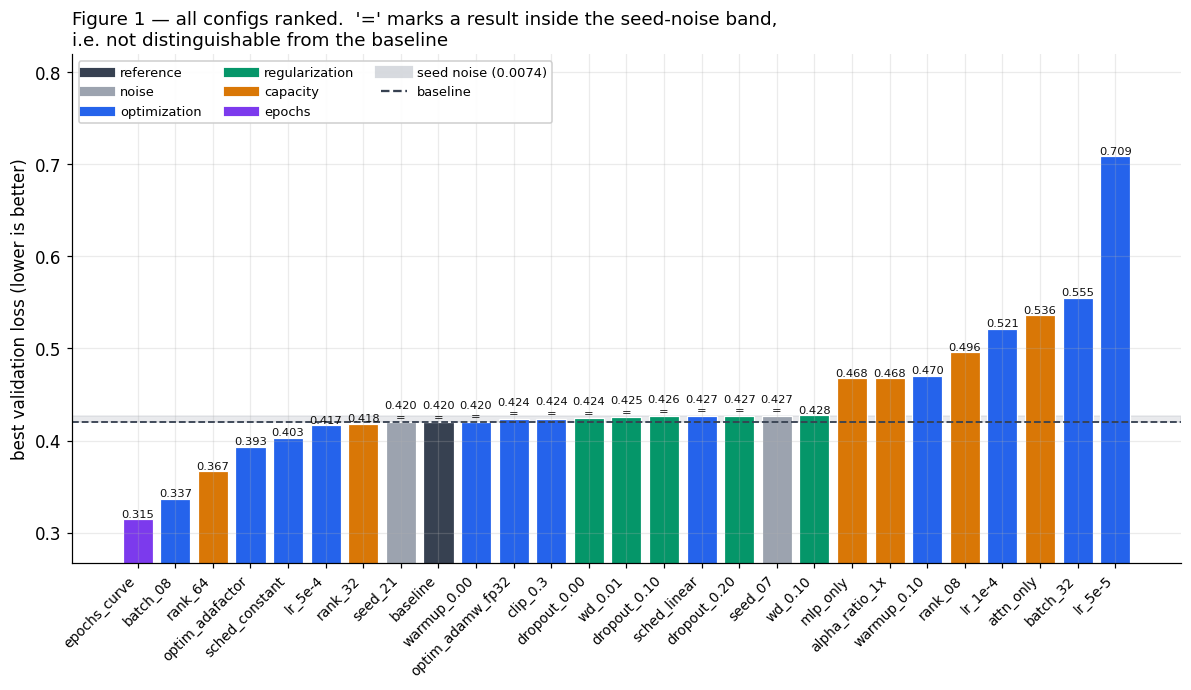

   saved 02_learning_rate.png


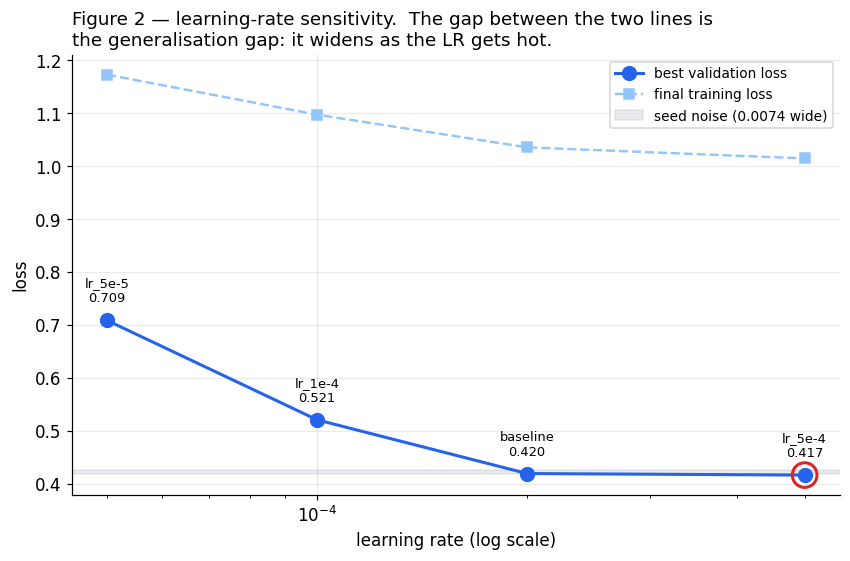

   saved 03_overfitting_curve.png


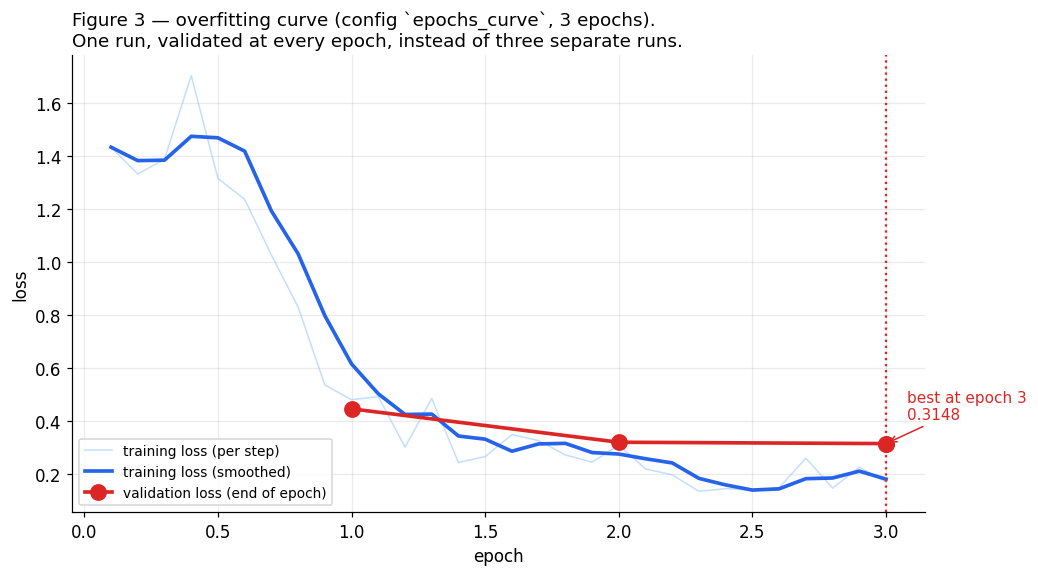

In [10]:
# ---- 1. leaderboard, coloured by family, with the noise band -------------------------------
@fig_guard(1, "leaderboard")
def _f1():
    d = sweep_df.sort_values("best_eval_loss")
    fig, ax = plt.subplots(figsize=(13, 6))
    cols = [FAM_COLOR.get(f, "#666") for f in d["family"]]
    bars = ax.bar(range(len(d)), d["best_eval_loss"], color=cols,
                  edgecolor="white", linewidth=0.8)
    band(ax)
    ax.axhline(BASELINE_LOSS, color="#374151", ls="--", lw=1.2, label="baseline")
    ax.set_xticks(range(len(d)))
    ax.set_xticklabels(d["config"], rotation=45, ha="right", fontsize=9)
    lo = min(d["best_eval_loss"]); hi = max(d["best_eval_loss"])
    ax.set_ylim(lo - 0.12 * (hi - lo + 1e-6), hi + 0.28 * (hi - lo + 1e-6))
    for i, (v, c) in enumerate(zip(d["best_eval_loss"], d["config"])):
        inside = HAVE_NOISE and NOISE_LO <= v <= NOISE_HI
        ax.text(i, v, f"{v:.3f}" + ("" if not inside else "\n=" ), ha="center",
                va="bottom", fontsize=7.5, color="#111")
    ax.set_ylabel("best validation loss (lower is better)")
    ax.set_title("Figure 1 — all configs ranked.  '=' marks a result inside the seed-noise "
                 "band,\ni.e. not distinguishable from the baseline", loc="left", fontsize=12)
    handles = [Line2D([], [], color=v, lw=6, label=k) for k, v in FAM_COLOR.items()
               if k in set(d["family"])]
    if HAVE_NOISE and NOISE_W > 0:
        handles.append(Line2D([], [], color="#9ca3af", lw=8, alpha=0.4,
                              label=f"seed noise ({NOISE_W:.4f})"))
    handles.append(Line2D([], [], color="#374151", ls="--", label="baseline"))
    ax.legend(handles=handles, loc="upper left", fontsize=8.5, ncol=3, framealpha=0.95)
    savefig(fig, "01_leaderboard.png"); plt.show()


# ---- 2. learning-rate sensitivity -----------------------------------------------------------
@fig_guard(2, "learning rate")
def _f2():
    d = sweep_df[sweep_df["config"].str.startswith("lr_") |
                 (sweep_df["config"] == "baseline")].sort_values("lr")
    if len(d) < 3:
        raise ValueError("need at least 3 learning-rate points")
    fig, ax = plt.subplots(figsize=(9, 5.2))
    ax.plot(d["lr"], d["best_eval_loss"], "o-", color=FAM_COLOR["optimization"],
            lw=2, ms=9, label="best validation loss")
    ax.plot(d["lr"], d["train_loss"], "s--", color="#93c5fd", lw=1.6, ms=7,
            label="final training loss")
    band(ax)
    ax.set_xscale("log")
    for _, r in d.iterrows():
        ax.annotate(f"{r['config']}\n{r['best_eval_loss']:.3f}",
                    (r["lr"], r["best_eval_loss"]), textcoords="offset points",
                    xytext=(0, 12), ha="center", fontsize=8.5)
    _b = d.loc[d["best_eval_loss"].idxmin()]
    ax.scatter([_b["lr"]], [_b["best_eval_loss"]], s=260, facecolors="none",
               edgecolors="#dc2626", lw=2, zorder=5)
    ax.set_xlabel("learning rate (log scale)")
    ax.set_ylabel("loss")
    ax.set_title("Figure 2 — learning-rate sensitivity.  The gap between the two lines is\n"
                 "the generalisation gap: it widens as the LR gets hot.",
                 loc="left", fontsize=12)
    ax.legend(fontsize=9)
    savefig(fig, "02_learning_rate.png"); plt.show()


# ---- 3. the overfitting curve ----------------------------------------------------------------
@fig_guard(3, "overfitting")
def _f3():
    log = ALL_LOGS.get("epochs_curve")
    if log is None:
        raise ValueError("epochs_curve did not run")
    tr = log.dropna(subset=["loss"])[["epoch", "loss"]]
    ev = log.dropna(subset=["eval_loss"])[["epoch", "eval_loss"]]
    fig, ax = plt.subplots(figsize=(10, 5.4))
    ax.plot(tr["epoch"], tr["loss"], color="#93c5fd", lw=1, alpha=0.55,
            label="training loss (per step)")
    _sm = tr.set_index("epoch")["loss"].rolling(max(3, len(tr)//12), min_periods=1).mean()
    ax.plot(_sm.index, _sm.values, color=FAM_COLOR["optimization"], lw=2.4,
            label="training loss (smoothed)")
    ax.plot(ev["epoch"], ev["eval_loss"], "o-", color="#dc2626", lw=2.4, ms=10,
            label="validation loss (end of epoch)")
    if len(ev) >= 2:
        _best = ev.loc[ev["eval_loss"].idxmin()]
        ax.axvline(_best["epoch"], color="#dc2626", ls=":", lw=1.5)
        ax.annotate(f"best at epoch {_best['epoch']:.0f}\n{_best['eval_loss']:.4f}",
                    (_best["epoch"], _best["eval_loss"]), textcoords="offset points",
                    xytext=(14, 16), fontsize=10, color="#dc2626",
                    arrowprops=dict(arrowstyle="->", color="#dc2626"))
        if float(ev.iloc[-1]["eval_loss"]) > float(_best["eval_loss"]) + 1e-4:
            ax.annotate("validation turns back up while training keeps falling\n"
                        "-> this is where it starts memorising",
                        (float(ev.iloc[-1]["epoch"]), float(ev.iloc[-1]["eval_loss"])),
                        textcoords="offset points", xytext=(-210, 26), fontsize=9.5,
                        color="#7f1d1d",
                        arrowprops=dict(arrowstyle="->", color="#7f1d1d"))
    ax.set_xlabel("epoch"); ax.set_ylabel("loss")
    ax.set_title("Figure 3 — overfitting curve (config `epochs_curve`, 3 epochs).\n"
                 "One run, validated at every epoch, instead of three separate runs.",
                 loc="left", fontsize=12)
    ax.legend(fontsize=9)
    savefig(fig, "03_overfitting_curve.png"); plt.show()

   saved 04_capacity.png


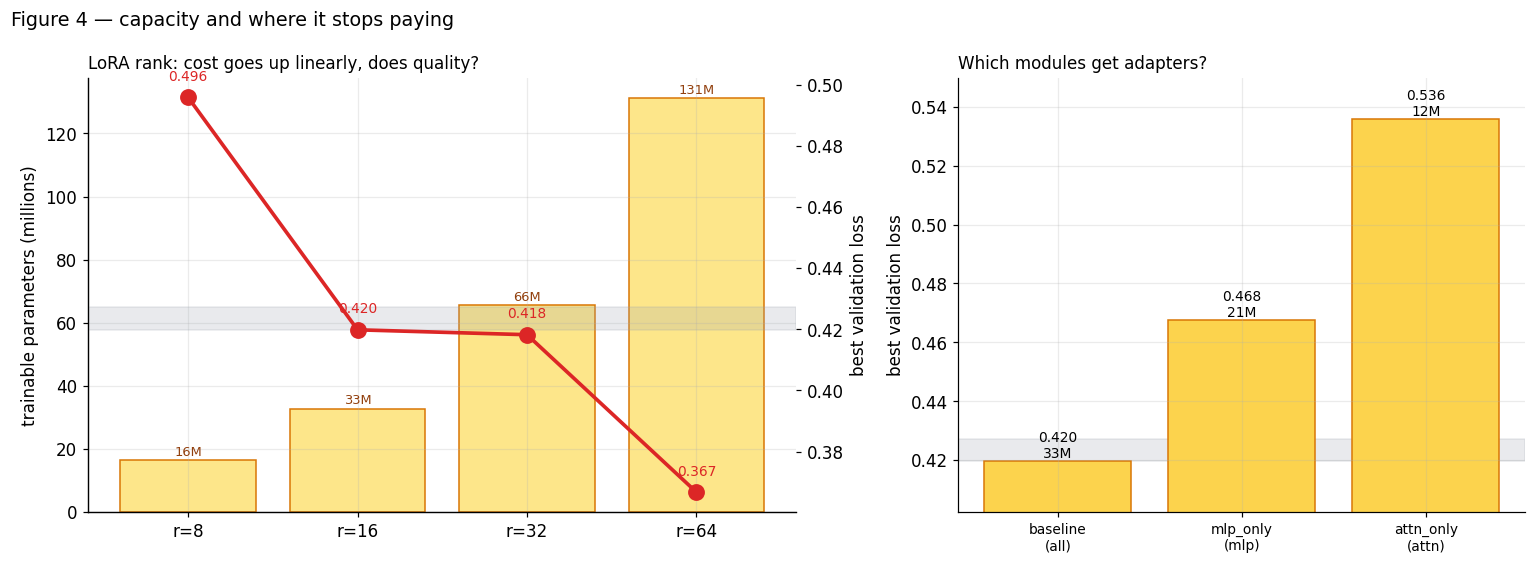

   saved 05_regularization.png


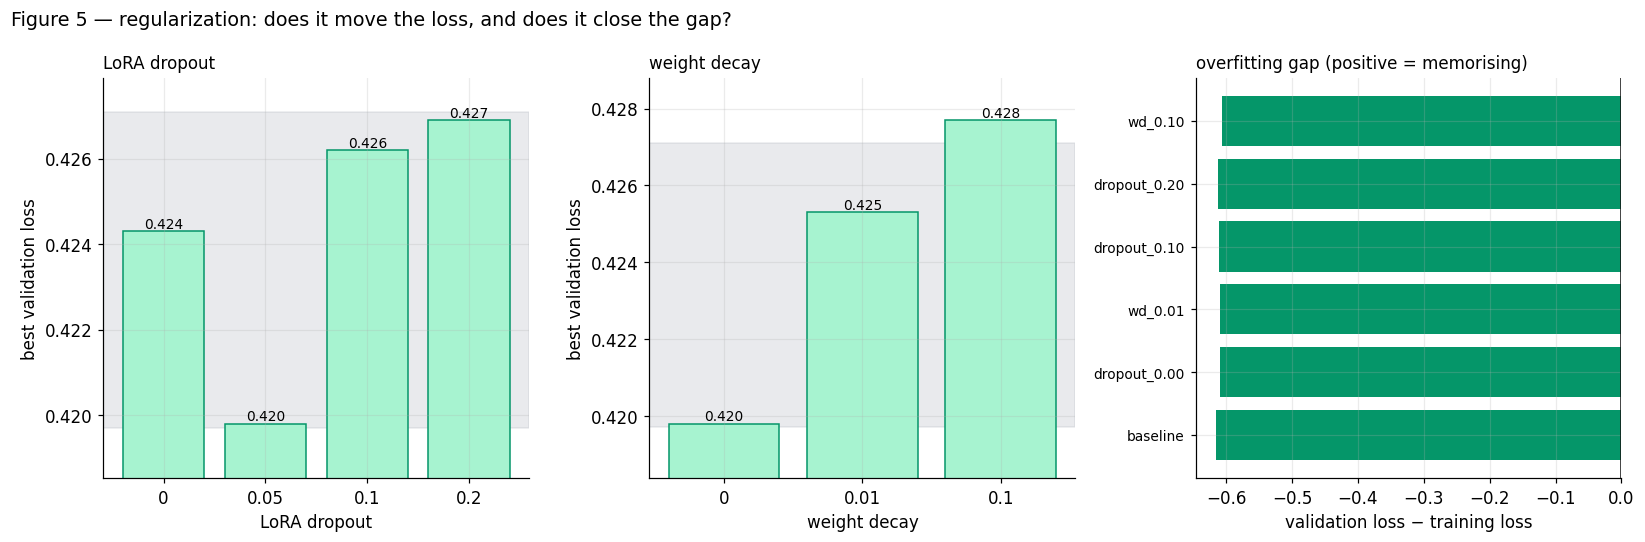

   saved 06_optimizer_schedule.png


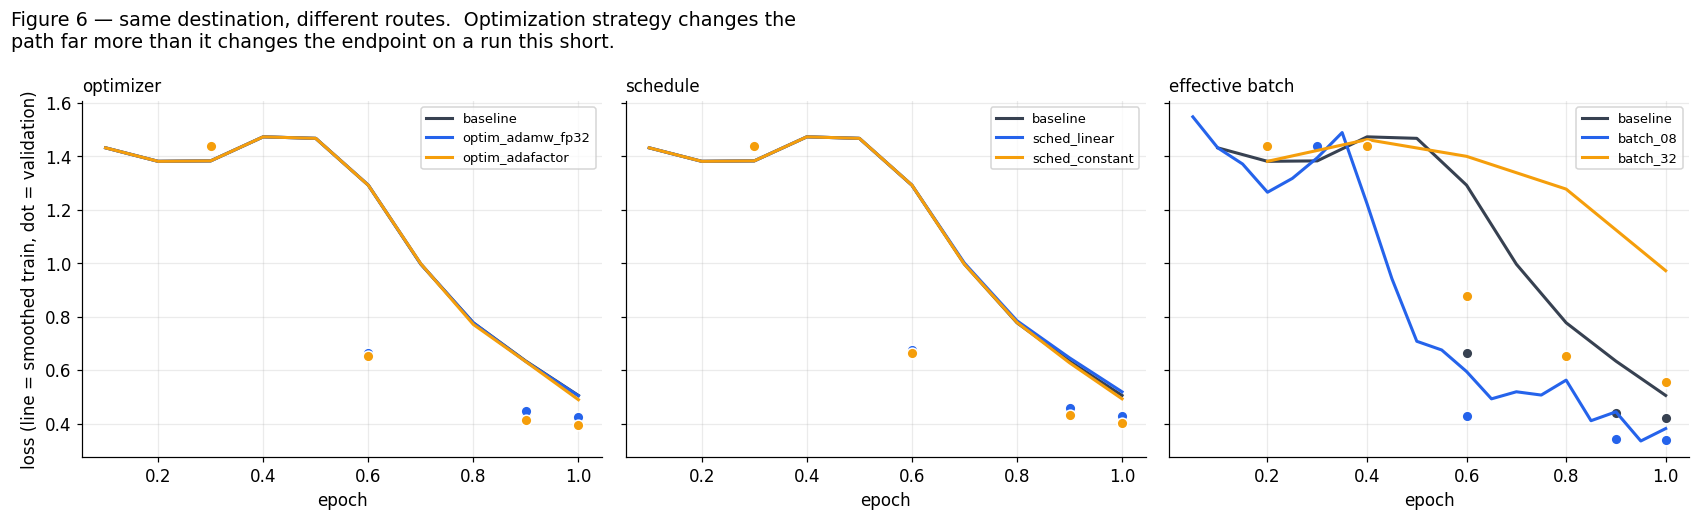

In [11]:
# ---- 4. capacity: rank vs loss vs trainable parameters ---------------------------------------
@fig_guard(4, "capacity")
def _f4():
    d = sweep_df[sweep_df["config"].str.startswith("rank_") |
                 (sweep_df["config"] == "baseline")].sort_values("lora_r")
    mod = sweep_df[sweep_df["config"].isin(["attn_only", "mlp_only", "baseline"])]
    fig, (ax, ax2) = plt.subplots(1, 2, figsize=(14, 5.2),
                                  gridspec_kw={"width_ratios": [1.25, 1]})

    ax.bar(range(len(d)), d["trainable_M"], color="#fde68a", edgecolor="#d97706",
           label="trainable parameters (M)")
    ax.set_xticks(range(len(d)))
    ax.set_xticklabels([f"r={int(r)}" for r in d["lora_r"]])
    ax.set_ylabel("trainable parameters (millions)")
    axb = ax.twinx()
    axb.plot(range(len(d)), d["best_eval_loss"], "o-", color="#dc2626", lw=2.4, ms=10,
             label="best validation loss")
    if HAVE_NOISE and NOISE_W > 0:
        axb.axhspan(NOISE_LO, NOISE_HI, color="#9ca3af", alpha=0.22, zorder=0)
    axb.set_ylabel("best validation loss")
    axb.grid(False)
    for i, (v, p) in enumerate(zip(d["best_eval_loss"], d["trainable_M"])):
        axb.annotate(f"{v:.3f}", (i, v), textcoords="offset points", xytext=(0, 11),
                     ha="center", fontsize=9, color="#dc2626")
        ax.annotate(f"{p:.0f}M", (i, p), textcoords="offset points", xytext=(0, 3),
                    ha="center", fontsize=8.5, color="#92400e")
    ax.set_title("LoRA rank: cost goes up linearly, does quality?", loc="left", fontsize=11)

    ax2.bar(range(len(mod)), mod["best_eval_loss"], color="#fcd34d", edgecolor="#d97706")
    ax2.set_xticks(range(len(mod)))
    ax2.set_xticklabels([f"{c}\n({m})" for c, m in zip(mod["config"], mod["modules"])],
                        fontsize=9)
    if HAVE_NOISE and NOISE_W > 0:
        ax2.axhspan(NOISE_LO, NOISE_HI, color="#9ca3af", alpha=0.22, zorder=0)
    _lo, _hi = mod["best_eval_loss"].min(), mod["best_eval_loss"].max()
    ax2.set_ylim(_lo - 0.15 * (_hi - _lo + 1e-6), _hi + 0.12 * (_hi - _lo + 1e-6))
    for i, (v, p) in enumerate(zip(mod["best_eval_loss"], mod["trainable_M"])):
        ax2.text(i, v, f"{v:.3f}\n{p:.0f}M", ha="center", va="bottom", fontsize=9)
    ax2.set_ylabel("best validation loss")
    ax2.set_title("Which modules get adapters?", loc="left", fontsize=11)
    fig.suptitle("Figure 4 — capacity and where it stops paying", x=0.005, ha="left",
                 fontsize=12.5)
    fig.tight_layout()
    savefig(fig, "04_capacity.png"); plt.show()


# ---- 5. regularization ------------------------------------------------------------------------
@fig_guard(5, "regularization")
def _f5():
    dro = sweep_df[sweep_df["config"].str.startswith("dropout_") |
                   (sweep_df["config"] == "baseline")].sort_values("dropout")
    wd  = sweep_df[sweep_df["config"].str.startswith("wd_") |
                   (sweep_df["config"] == "baseline")].sort_values("weight_decay")
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    for ax, d, xcol, name in ((axes[0], dro, "dropout", "LoRA dropout"),
                              (axes[1], wd, "weight_decay", "weight decay")):
        ax.bar(range(len(d)), d["best_eval_loss"], color="#a7f3d0", edgecolor="#059669")
        if HAVE_NOISE and NOISE_W > 0:
            ax.axhspan(NOISE_LO, NOISE_HI, color="#9ca3af", alpha=0.22, zorder=0)
        ax.set_xticks(range(len(d)))
        ax.set_xticklabels([f"{v:g}" for v in d[xcol]])
        _lo, _hi = d["best_eval_loss"].min(), d["best_eval_loss"].max()
        ax.set_ylim(_lo - 0.18 * (_hi - _lo + 1e-6), _hi + 0.14 * (_hi - _lo + 1e-6))
        for i, v in enumerate(d["best_eval_loss"]):
            ax.text(i, v, f"{v:.3f}", ha="center", va="bottom", fontsize=9)
        ax.set_xlabel(name); ax.set_ylabel("best validation loss")
        ax.set_title(name, loc="left", fontsize=11)

    reg = sweep_df[sweep_df["family"].isin(["regularization", "reference"])]
    axes[2].barh(range(len(reg)), reg["overfit_gap"],
                 color=["#059669" if g < 0 else "#dc2626" for g in reg["overfit_gap"]])
    axes[2].set_yticks(range(len(reg)))
    axes[2].set_yticklabels(reg["config"], fontsize=9)
    axes[2].axvline(0, color="#111", lw=1)
    axes[2].set_xlabel("validation loss − training loss")
    axes[2].set_title("overfitting gap (positive = memorising)", loc="left", fontsize=11)
    fig.suptitle("Figure 5 — regularization: does it move the loss, and does it close the gap?",
                 x=0.005, ha="left", fontsize=12.5)
    fig.tight_layout()
    savefig(fig, "05_regularization.png"); plt.show()


# ---- 6. optimizer and schedule traces -----------------------------------------------------------
@fig_guard(6, "optimizer / schedule")
def _f6():
    groups = {
        "optimizer": ["baseline", "optim_adamw_fp32", "optim_adafactor"],
        "schedule":  ["baseline", "sched_linear", "sched_constant"],
        "effective batch": ["baseline", "batch_08", "batch_32"],
    }
    fig, axes = plt.subplots(1, 3, figsize=(15.5, 4.8), sharey=True)
    palette = ["#374151", "#2563eb", "#f59e0b", "#059669"]
    for ax, (name, labels) in zip(axes, groups.items()):
        drew = 0
        for c, lab in zip(palette, labels):
            log = ALL_LOGS.get(lab)
            if log is None or "loss" not in log.columns:
                continue
            tr = log.dropna(subset=["loss"])
            w = max(3, len(tr) // 10)
            ax.plot(tr["epoch"], tr["loss"].rolling(w, min_periods=1).mean(),
                    color=c, lw=2, label=f"{lab}")
            ev = log.dropna(subset=["eval_loss"]) if "eval_loss" in log.columns else None
            if ev is not None and len(ev):
                ax.plot(ev["epoch"], ev["eval_loss"], "o", color=c, ms=7, mec="white")
            drew += 1
        if not drew:
            raise ValueError(f"no logs for {name}")
        ax.set_xlabel("epoch")
        ax.set_title(name, loc="left", fontsize=11)
        ax.legend(fontsize=8.5)
    axes[0].set_ylabel("loss (line = smoothed train, dot = validation)")
    fig.suptitle("Figure 6 — same destination, different routes.  Optimization strategy "
                 "changes the\npath far more than it changes the endpoint on a run this short.",
                 x=0.005, ha="left", fontsize=12.5)
    fig.tight_layout()
    savefig(fig, "06_optimizer_schedule.png"); plt.show()

   saved 07_gradient_norms.png


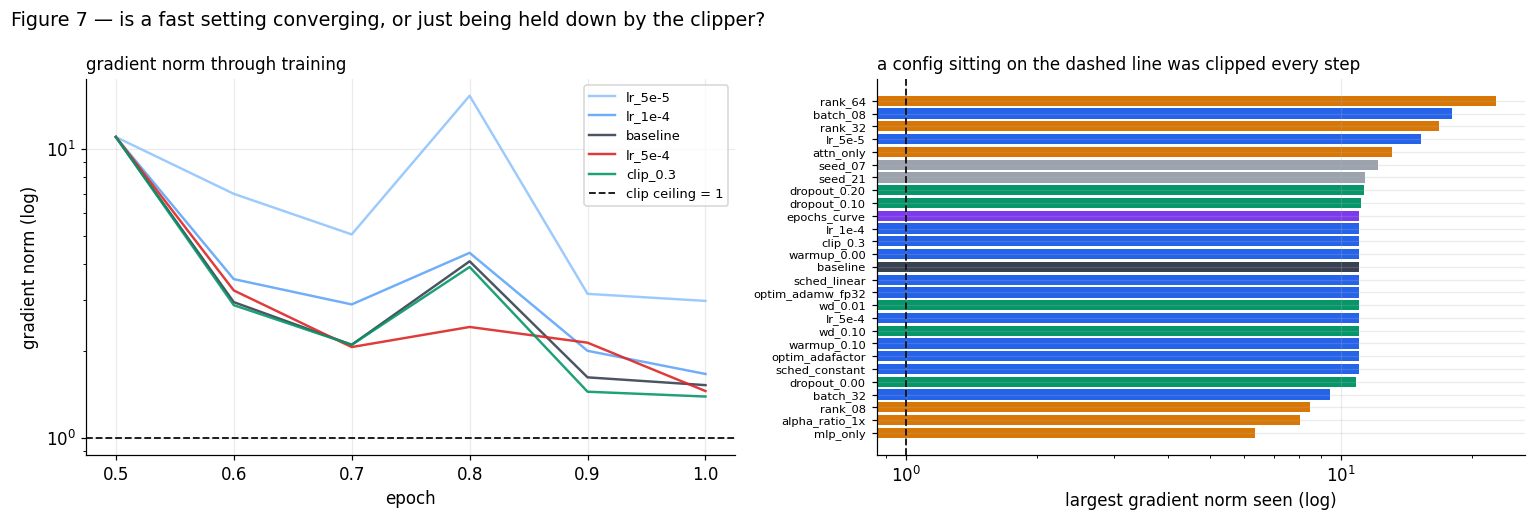

   saved 08_cost_benefit.png


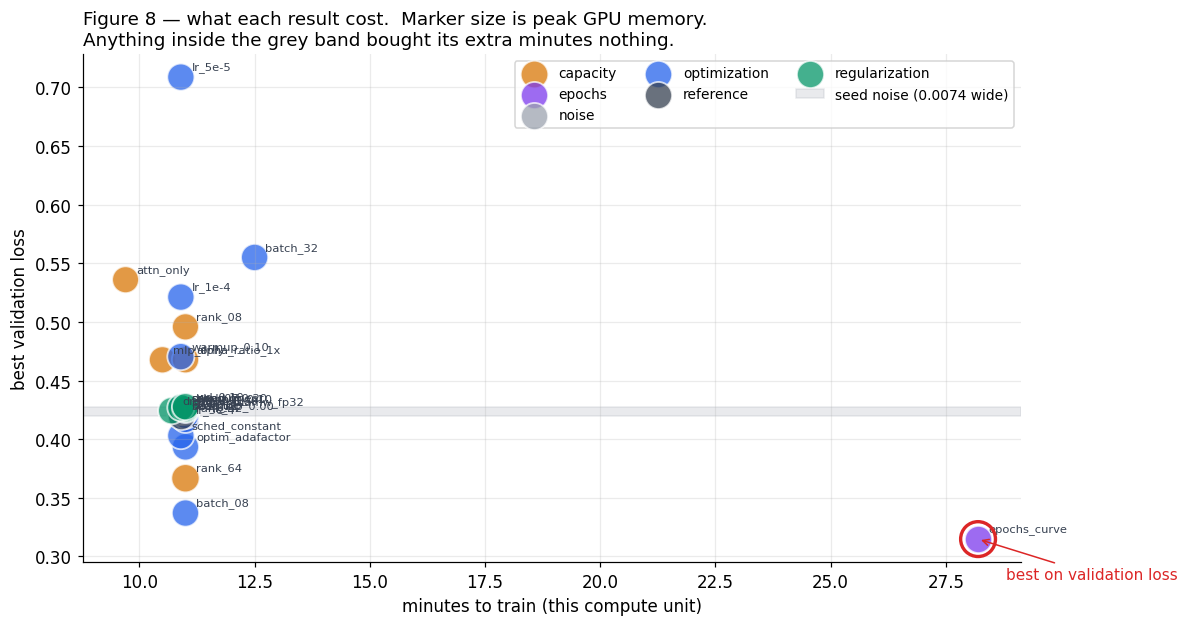


8 figures written to /kaggle/working/hparam_study/figures


In [12]:
# ---- 7. gradient norms ------------------------------------------------------------------------
@fig_guard(7, "gradient norms")
def _f7():
    labels = [l for l in ["lr_5e-5", "lr_1e-4", "baseline", "lr_5e-4", "clip_0.3"]
              if l in ALL_LOGS]
    fig, (ax, ax2) = plt.subplots(1, 2, figsize=(14, 4.8))
    palette = ["#93c5fd", "#60a5fa", "#374151", "#dc2626", "#059669"]
    for c, lab in zip(palette, labels):
        log = ALL_LOGS[lab]
        if "grad_norm" not in log.columns:
            continue
        g = log.dropna(subset=["grad_norm"])
        ax.plot(g["epoch"], g["grad_norm"], color=c, lw=1.6, label=lab, alpha=0.9)
    _clip = float(BASE["max_grad_norm"])
    ax.axhline(_clip, color="#111", ls="--", lw=1.2, label=f"clip ceiling = {_clip:g}")
    ax.set_yscale("log")
    ax.set_xlabel("epoch"); ax.set_ylabel("gradient norm (log)")
    ax.set_title("gradient norm through training", loc="left", fontsize=11)
    ax.legend(fontsize=8.5)

    d = sweep_df.dropna(subset=["grad_norm_max"]).sort_values("grad_norm_max")
    ax2.barh(range(len(d)), d["grad_norm_max"],
             color=[FAM_COLOR.get(f, "#666") for f in d["family"]])
    ax2.axvline(_clip, color="#111", ls="--", lw=1.2)
    ax2.set_yticks(range(len(d)))
    ax2.set_yticklabels(d["config"], fontsize=7.5)
    ax2.set_xscale("log")
    ax2.set_xlabel("largest gradient norm seen (log)")
    ax2.set_title("a config sitting on the dashed line was clipped every step", loc="left",
                  fontsize=11)
    fig.suptitle("Figure 7 — is a fast setting converging, or just being held down by the "
                 "clipper?", x=0.005, ha="left", fontsize=12.5)
    fig.tight_layout()
    savefig(fig, "07_gradient_norms.png"); plt.show()


# ---- 8. cost / benefit ---------------------------------------------------------------------------
@fig_guard(8, "cost/benefit")
def _f8():
    d = sweep_df.copy()
    fig, ax = plt.subplots(figsize=(11, 6))
    for fam, sub in d.groupby("family"):
        ax.scatter(sub["minutes"], sub["best_eval_loss"],
                   s=40 + 300 * (sub["peak_vram_gb"] / max(d["peak_vram_gb"].max(), 1e-6)),
                   color=FAM_COLOR.get(fam, "#666"), alpha=0.75, edgecolors="white",
                   linewidth=1.2, label=fam)
    band(ax)
    for _, r in d.iterrows():
        ax.annotate(r["config"], (r["minutes"], r["best_eval_loss"]),
                    textcoords="offset points", xytext=(7, 5), fontsize=7.5, color="#374151")
    _b = d.loc[d["best_eval_loss"].idxmin()]
    ax.scatter([_b["minutes"]], [_b["best_eval_loss"]], s=520, facecolors="none",
               edgecolors="#dc2626", lw=2.2, zorder=5)
    ax.annotate("best on validation loss", (_b["minutes"], _b["best_eval_loss"]),
                textcoords="offset points", xytext=(18, -26), fontsize=10, color="#dc2626",
                arrowprops=dict(arrowstyle="->", color="#dc2626"))
    ax.set_xlabel("minutes to train (this compute unit)")
    ax.set_ylabel("best validation loss")
    ax.set_title("Figure 8 — what each result cost.  Marker size is peak GPU memory.\n"
                 "Anything inside the grey band bought its extra minutes nothing.",
                 loc="left", fontsize=12)
    ax.legend(fontsize=9, ncol=3)
    savefig(fig, "08_cost_benefit.png"); plt.show()

print(f"\n{len(FIGS)} figures written to {FIG_DIR}")

## 7. The leaderboard

One table, sorted by validation loss, with everything a reader needs to check the claim.

`vs_base` is the change against the baseline — **negative is better.** `verdict` converts that
into plain language using the seed-noise band measured above, and it is deliberately blunt:

* **`= noise`** — the result sits inside the band the same config produced across three seeds.
  It is not evidence of anything. Most of the 27 rows are expected to land here, and saying so is
  the honest finding, not a failure of the experiment.
* **`better`** / **`worse`** — outside the band, in the named direction.

The second table is the same thing collapsed to one line per family: the actual answer to
"which knobs matter for this task".

In [13]:
step(7, "Leaderboard and findings")

lead = sweep_df.copy()
lead["vs_base"] = (lead["best_eval_loss"] - BASELINE_LOSS).round(4)

def _verdict(v):
    if not HAVE_NOISE or NOISE_W <= 0:
        return "?"
    if abs(v) <= NOISE_W:
        return "= noise"
    return "better" if v < 0 else "worse"

lead["verdict"] = lead["vs_base"].map(_verdict)
lead["rank"] = range(1, len(lead) + 1)

VIEW = ["rank", "config", "family", "lora_r", "alpha_over_r", "modules", "lr", "sched",
        "optim", "eff_batch", "warmup", "dropout", "weight_decay", "epochs", "seed",
        "trainable_M", "train_loss", "best_eval_loss", "perplexity", "overfit_gap",
        "vs_base", "verdict", "grad_norm_max", "peak_vram_gb", "minutes"]
VIEW = [c for c in VIEW if c in lead.columns]

pd.set_option("display.width", 250, "display.max_columns", 60)
print("=" * 118)
print(f"HYPERPARAMETER STUDY -- {len(lead)} configs, {len(sweep_ds)} training rows and "
      f"{len(val_ds)} validation rows each")
print(f"ranked on best validation loss   |   seed-noise band = {NOISE_W:.4f}   |   "
      f"baseline = {BASELINE_LOSS:.4f}")
print("=" * 118)
print(lead[VIEW].to_string(index=False))

# ---- one line per family -------------------------------------------------------------------
rows = []
for fam, sub in lead[lead["family"] != "noise"].groupby("family"):
    b, w = sub.loc[sub["best_eval_loss"].idxmin()], sub.loc[sub["best_eval_loss"].idxmax()]
    real = sub[sub["verdict"] != "= noise"]
    rows.append({
        "family": fam,
        "configs": len(sub),
        "best": f"{b['config']} ({b['best_eval_loss']:.4f})",
        "worst": f"{w['config']} ({w['best_eval_loss']:.4f})",
        "spread": round(float(w["best_eval_loss"] - b["best_eval_loss"]), 4),
        "beyond_noise": f"{len(real)}/{len(sub)}",
        "matters?": ("YES" if float(w["best_eval_loss"] - b["best_eval_loss"]) > NOISE_W
                     else "not measurably"),
    })
family_df = pd.DataFrame(rows).sort_values("spread", ascending=False)

print("\n" + "=" * 118)
print("WHICH FAMILY OF SETTINGS ACTUALLY MATTERS (spread within the family vs the noise band)")
print("=" * 118)
print(family_df.to_string(index=False))

# ---- markdown, ready to paste into the milestone document -----------------------------------
def _family_md():
    try:
        return family_df.to_markdown(index=False)
    except Exception:      # tabulate missing on some images
        return "```\n" + family_df.to_string(index=False) + "\n```"

MD = ["| " + " | ".join(VIEW) + " |", "|" + "---|" * len(VIEW)]
for _, r in lead[VIEW].iterrows():
    MD.append("| " + " | ".join(f"{r[c]:g}" if isinstance(r[c], float) else str(r[c])
                                for c in VIEW) + " |")
MD_TABLE = "\n".join(MD)
open(os.path.join(OUTPUT_DIR, "leaderboard.md"), "w").write(
    f"# Milestone 4 - hyperparameter study\n\n"
    f"{len(lead)} configs, {len(sweep_ds)} training rows / {len(val_ds)} validation rows each, "
    f"window {MAX_SEQ_LEN} tokens.\nSeed-noise band {NOISE_W:.4f}; baseline "
    f"{BASELINE_LOSS:.4f}.\n\n{MD_TABLE}\n\n## By family\n\n"
    + _family_md() + "\n")
print(f"\nmarkdown version written to {OUTPUT_DIR}/leaderboard.md (paste straight into the "
      "report)")

# ---- the findings, stated ---------------------------------------------------------------------
print("\n" + "=" * 118)
print("FINDINGS")
print("=" * 118)
_beat = lead[(lead["verdict"] == "better") & (lead["family"] != "noise")]
if len(_beat):
    print(f"{len(_beat)} config(s) beat the baseline by more than run-to-run noise:")
    for _, r in _beat.iterrows():
        print(f"   {r['config']:<18} {r['vs_base']:+.4f}   ({r['question']})")
else:
    print("No config beat the baseline by more than run-to-run noise. On a 160-row slice that "
          "is\na result in itself: the default QLoRA recipe is already at the point where the "
          "data,\nnot the settings, is the limiting factor.")
_hurt = lead[lead["verdict"] == "worse"]
if len(_hurt):
    print(f"\n{len(_hurt)} config(s) were measurably worse -- the settings that do have "
          "teeth:")
    for _, r in _hurt.iterrows():
        print(f"   {r['config']:<18} {r['vs_base']:+.4f}")
print(f"\nWinner: '{BEST_LABEL}' at {lead.iloc[0]['best_eval_loss']:.4f} "
      f"(perplexity {lead.iloc[0]['perplexity']:.2f}).")
if lead.iloc[0]["verdict"] == "= noise":
    print("   -> it is inside the noise band. Report it as 'the best of several equivalent "
          "settings',\n      not as a demonstrated improvement.")


--- step 6 done in 0.1 min (total so far 364.9 min) ---

STEP 7/8  Leaderboard and findings
HYPERPARAMETER STUDY -- 27 configs, 160 training rows and 48 validation rows each
ranked on best validation loss   |   seed-noise band = 0.0074   |   baseline = 0.4198
 rank           config         family  lora_r  alpha_over_r modules      lr    sched            optim  eff_batch  warmup  dropout  weight_decay  epochs  seed  trainable_M  train_loss  best_eval_loss  perplexity  overfit_gap  vs_base verdict  grad_norm_max  peak_vram_gb  minutes
    1     epochs_curve         epochs      16           2.0     all 0.00020   cosine paged_adamw_8bit         16    0.03     0.05          0.00       3    13        32.79      0.5448          0.3148        1.37      -0.2301  -0.1050  better         10.990          9.89     28.2
    2         batch_08   optimization      16           2.0     all 0.00020   cosine paged_adamw_8bit          8    0.03     0.05          0.00       1    13        32.79      0.822

## 8. Package everything

Everything under `/kaggle/working` becomes this notebook's output when the session ends. The zip
bundles the small files for a one-click download; the saved adapter is left out of it, since it
is already a directory the next notebook can attach directly.

In [14]:
step(8, "Package everything")

sweep_df.to_csv(os.path.join(OUTPUT_DIR, "hyperparameter_sweep.csv"), index=False)
lead[VIEW].to_csv(os.path.join(OUTPUT_DIR, "leaderboard.csv"), index=False)
family_df.to_csv(os.path.join(OUTPUT_DIR, "family_summary.csv"), index=False)

# Every step of every run, so a curve can be redrawn without retraining anything.
curves = pd.concat([d.assign(config=k) for k, d in ALL_LOGS.items()], ignore_index=True)
curves.to_csv(os.path.join(OUTPUT_DIR, "training_curves.csv"), index=False)

config_str = json.dumps(dict(base=BASE, configs=[c["label"] for c in SWEEP_CONFIGS],
                             rows=len(sweep_ds), val=len(val_ds), seq=MAX_SEQ_LEN,
                             data=DATASET_MANIFEST.get("config_hash")), sort_keys=True)
RUN_CONFIG_HASH = hashlib.sha256(config_str.encode()).hexdigest()[:12]

manifest = {
    "config_hash": RUN_CONFIG_HASH,
    "upstream_dataset_config_hash": DATASET_MANIFEST.get("config_hash"),
    "built_utc": time.strftime("%Y-%m-%dT%H:%M:%SZ", time.gmtime()),
    "stage": "14_hyperparameter_study",
    "purpose": "Milestone 4: training runs varying hyperparameters, optimization strategies "
               "and regularization techniques. No final-model training and no test-set "
               "evaluation happen in this notebook.",
    "student_model_id": STUDENT_MODEL_ID,
    "student_trained_on": STUDENT_TRAINED_ON,
    "student_quantization": STUDENT_QUANT,
    "teacher_model_id": TEACHER_ID,
    "is_distillation": IS_DISTILLATION,
    "smoke_test": SMOKE_TEST,
    "upstream_smoke_test": DATASET_MANIFEST.get("smoke_test"),
    "protocol": {
        "design": "one factor at a time around a fixed baseline",
        "train_rows": len(sweep_ds), "val_rows": len(val_ds),
        "identical_rows_for_every_config": True,
        "max_seq_len": MAX_SEQ_LEN,
        "prompt_front_truncated_rows": {"train": TRUNC_TRAIN, "val": TRUNC_VAL},
        "rows_at_once": ROWS_AT_ONCE,
        "selection_metric": "best eval_loss observed during the run",
        "evals_per_epoch": EVALS_PER_EPOCH,
        "baseline": BASE,
        "train_language_mix": LANG_MIX_TRAIN,
    },
    "noise_floor": {"lo": NOISE_LO, "hi": NOISE_HI, "width": NOISE_W,
                    "seeds": sorted(_seed_runs["seed"].tolist()),
                    "note": "same config, different seeds. Any gap smaller than `width` is "
                            "not a result."},
    "n_configs_run": len(SWEEP_RESULTS),
    "failed_configs": FAILED,
    "best_config": BEST_LABEL,
    "best_config_verdict": str(lead.iloc[0]["verdict"]),
    "best_adapter_dir": ADAPTER_DIR if SAVE_BEST_ADAPTER else None,
    "best_adapter_note": ("trained on the 160-row study slice, NOT on the full dataset. "
                          "It is an artifact of the study, not a production model."),
    "results": SWEEP_RESULTS,
    "family_summary": json.loads(family_df.to_json(orient="records")),
    "figures": [os.path.basename(p) for p in FIGS],
}
with open(os.path.join(OUTPUT_DIR, "study_manifest.json"), "w", encoding="utf-8") as f:
    json.dump(manifest, f, ensure_ascii=False, indent=2, default=str)

BUNDLE = os.path.join(OUT_ROOT, "hparam_study_bundle")
shutil.rmtree(BUNDLE, ignore_errors=True)
os.makedirs(BUNDLE, exist_ok=True)
for _n in ("hyperparameter_sweep.csv", "leaderboard.csv", "leaderboard.md",
           "family_summary.csv", "training_curves.csv", "study_manifest.json"):
    _p = os.path.join(OUTPUT_DIR, _n)
    if os.path.exists(_p):
        shutil.copy(_p, BUNDLE)
shutil.copytree(FIG_DIR, os.path.join(BUNDLE, "figures"))
zip_path = shutil.make_archive(BUNDLE, "zip", BUNDLE)
shutil.rmtree(BUNDLE, ignore_errors=True)

finish_steps()
print("=" * 78)
print("DONE")
print("=" * 78)
for n, name, mins in STEP_LOG:
    print(f"   {n:>2}. {name:<36} {mins:>6.1f} min")
print(f"   {'':>2}  {'TOTAL':<36} {minutes_used():>6.1f} min")
print(f"\nbundle: {zip_path}")
print(f"figures: {len(FIGS)}   configs: {len(SWEEP_RESULTS)}"
      + (f"   failed: {len(FAILED)}" if FAILED else ""))
if SAVE_BEST_ADAPTER:
    print(f"adapter: {ADAPTER_DIR}")
vram_report("end")


--- step 7 done in 0.0 min (total so far 364.9 min) ---

STEP 8/8  Package everything
DONE
    1. Load the data from notebook 13          0.0 min
    2. Split into train and validation         0.0 min
    3. Load the student model                  0.8 min
    4. Turn the rows into tokens               0.0 min
    5. Run the hyperparameter study          364.0 min
    6. Figures                                 0.1 min
    7. Leaderboard and findings                0.0 min
    8. Package everything                      0.0 min
       TOTAL                                 364.9 min

bundle: /kaggle/working/hparam_study_bundle.zip
figures: 8   configs: 27
adapter: /kaggle/working/hparam_study/best_adapter
[end] gpu0 9.6 GB free   disk 20.8 GB free


## What this study shows, and what it does not

**What it shows.** Twenty-seven QLoRA fine-tunes of the same 4B student, each differing from a
fixed baseline in exactly one place, each given the same rows and the same number of optimizer
steps, each scored on the same held-back rows. Four families of setting — optimization,
regularization, capacity, epochs — were varied, and the same configuration was run on three seeds
so that every claim about a difference can be checked against how big a difference chance
produces. The figures and the leaderboard are all generated from that one run; nothing is quoted
from an earlier session.

**What it does not show.**

- **That the winner is the best setting for the full dataset.** Every config trained on a
  160-row slice. Settings interact with data volume — the learning rate that is right for 160
  rows is not necessarily right for 4,000 — so this ranks settings *at this scale* and should be
  described that way.
- **That the winner produces better answers.** Validation loss is next-token prediction. It
  cannot see whether the model invented a dosage, dropped its `Sources: [n]` line, or answered a
  Hinglish question in Hindi. Those are measured in the evaluation notebook against the held-out
  28 questions, and this notebook deliberately does not look at them: a test set consulted during
  selection is no longer a test set.
- **That gaps inside the noise band mean anything.** The band comes from three seeds of the same
  config. Three is enough to see the order of magnitude, not enough for a confidence interval.
  Where the leaderboard says `= noise`, the correct sentence for the report is "no measurable
  difference", not "slightly worse".
- **The effect of the 1024-token window.** Longer prompts lost tokens from the front. That
  applies equally to all 27 configs, so the *comparison* is sound, but the absolute losses are
  not the losses a full 1950-token window would produce. The affected row count is printed in
  step 4 and stored in the manifest.
- **Interactions.** This is a one-factor-at-a-time design, so it finds main effects only. If
  rank 64 only pays off at a lower learning rate, that combination was never tried. A grid over
  the two or three factors that came out with the widest spread is the natural next experiment.

**What to write in the report.** Lead with the family summary table, not the winner. The
interesting Milestone 4 finding is usually *which* class of setting has teeth on this task and
which is decoration — and if most of the grid lands inside the noise band, that is a measured
result about the data being the binding constraint, which is a stronger thing to say than
picking a winner out of a set of ties.